# Seaborn Complete Guide for Data Analysis & Data Visualization

A beginner-friendly guide covering Seaborn plots, parameters, use cases, and insights with practical examples.

**Table Of Contents**
1. Introduction
2. What is Seaborn?
3. Types of Seaborn Functions
4. Relational Plots
5. Distribution Plots
6. Categorical Plots
7. Regression Plots
8. Matrix Plots
9. Multi-Plot Grids

**Introduction**

**Importing Libraries**

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

**Importing Datasets for analysis**

In [83]:
tips=sns.load_dataset('tips')
gap=px.data.gapminder()
titanic=sns.load_dataset('titanic')
iris=px.data.iris()

**What is Seaborn**
<span>

Seaborn is a Python data visualization library built on top
of Matplotlib. It provides a high-level interface for creating
attractive, informative, and statistically meaningful graphs
with minimal code </span>

**Types of Seaborn Functions**


*   Axes level functions-<span>These functions draw a single plot on a single Matplotlib Axes. They can be used with plt.subplots() to create multiple plots.</span>


 - scatterplot()
 - lineplot()
 - histplot()
 - kdeplot()
 - rugplot()
 - stripplot()
 - swarmplot()
 - boxplot()
 -  violinplot()
 -  barplot()
 -  pointplot()
 - countplot()
- regplot()
 - residplot()
 - heatmap()



*   Figure level Functions-<span>These functions create one or more subplots and manage the entire figure automatically. They are useful for visualizing data across multiple categories.</span>


- relplot()
 - displot()
 - catplot()
 - lmplot()
 - pairplot()
 - jointplot()
 - FacetGrid()
 - PairGrid()
 - JointGrid()





**Relational** **Plots**

Axes level functions-These draw a plot on an existing Matplotlib axes.
*   Scatter Plot
*   Line Plot

Figure level function-These create the figure and one or more axes automatically.


*   relplot






<Axes: xlabel='total_bill', ylabel='tip'>

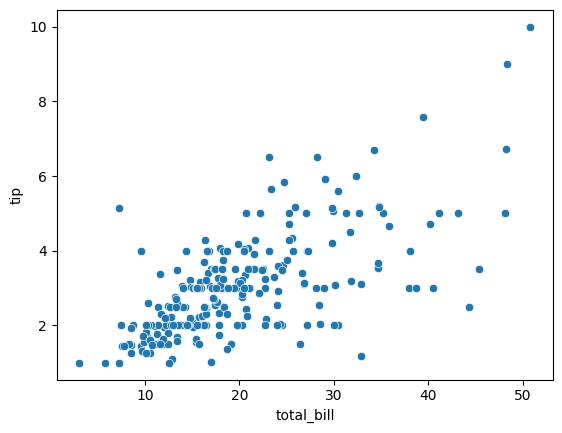

In [84]:
#Scatter plot
# Purpose: Shows the relationship between total bill and tip.
# Best Used For:
# - Finding correlations
# - Detecting clusters
# - Identifying outliers
# Insight:
# Customers with higher total bills generally leave higher tips.
# A few unusually high bills can also be identified as outliers.
sns.scatterplot(data=tips,x='total_bill',y='tip')

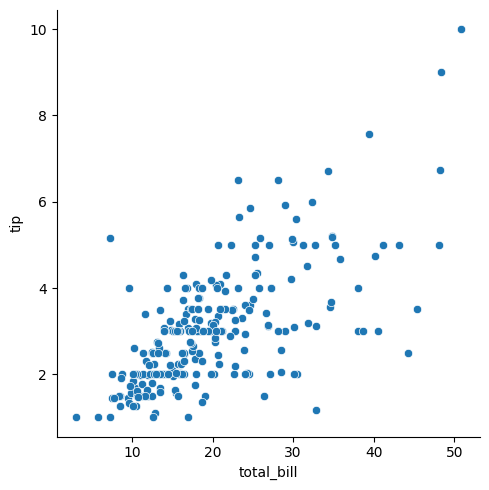

In [85]:
#figure level function
#relplot-same above analysis is done using relplot
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter')

<Axes: xlabel='total_bill', ylabel='tip'>

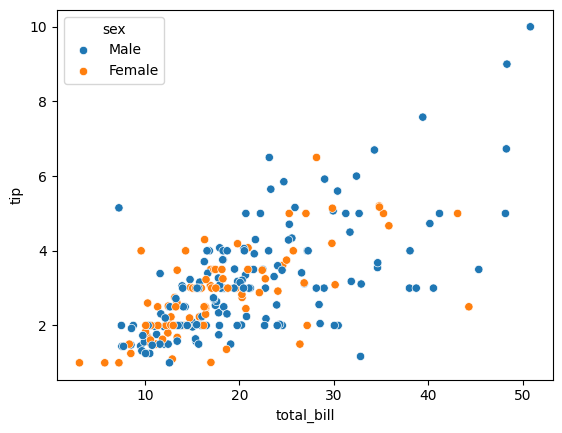

In [86]:
#hue-The hue parameter uses different colors to represent different categories of a variable.
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

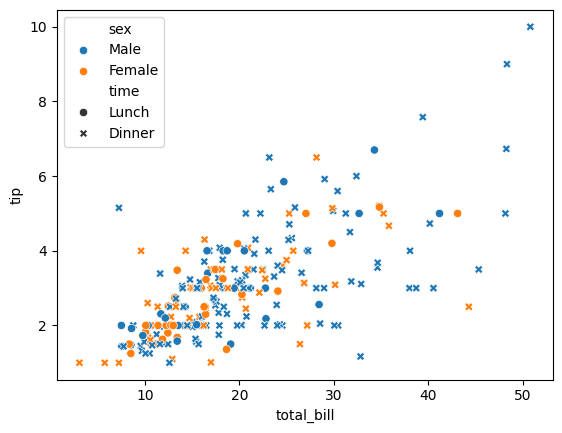

In [87]:
#style-Represents a variable using different marker shapes (for scatter plots) or different line styles (for line plots).
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex',style='time')

<Axes: xlabel='total_bill', ylabel='tip'>

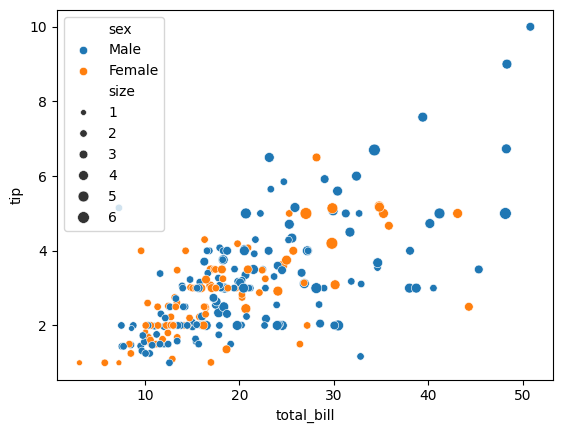

In [88]:
#size-Represents a variable by changing the size of the markers.
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex',size='size')

In [89]:
#line plot
# Purpose:Shows trends or changes over an ordered variable such as time.
# Best Used For:
# - Time series analysis
# - Trend analysis
# - Comparing multiple trends
#Insights:
#The graph indicates that the life expectancy has improved over time for India

<Axes: xlabel='year', ylabel='lifeExp'>

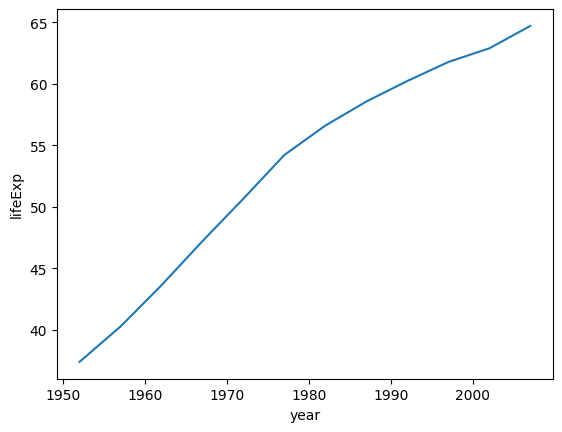

In [90]:
temp_df=gap[gap['country']=='India']
sns.lineplot(data=temp_df,x='year',y='lifeExp')

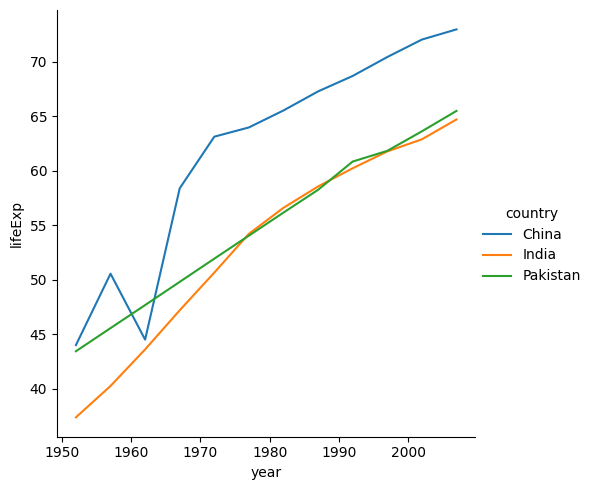

In [91]:
#same analysis is done through relplot figure level function  for 3 countires
# and hue parameter is added
temp_df=gap[gap['country'].isin(['India','China','Pakistan'])]
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country')

In [92]:
#Insights
#data is filtered according to 3 countries in diffrent continents
#from this plot we get to know the relationship bewtween year and life expectency for 3 differnt countries in diffrent continent
temp_df=gap[gap.country.isin(['India','Brazil','Germany'])]

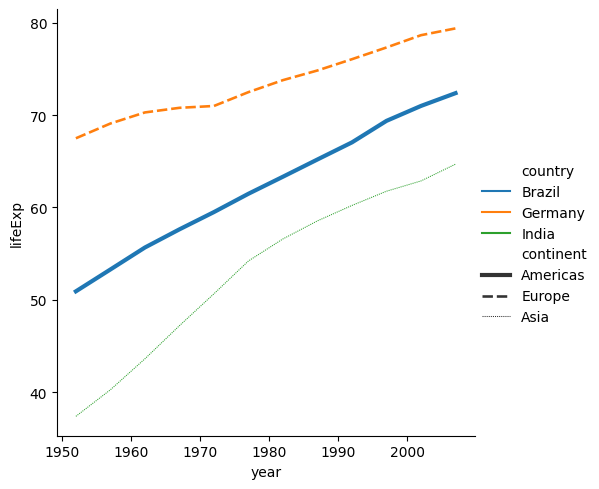

In [93]:
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country',style='continent',size='continent')

**Facet Plot**


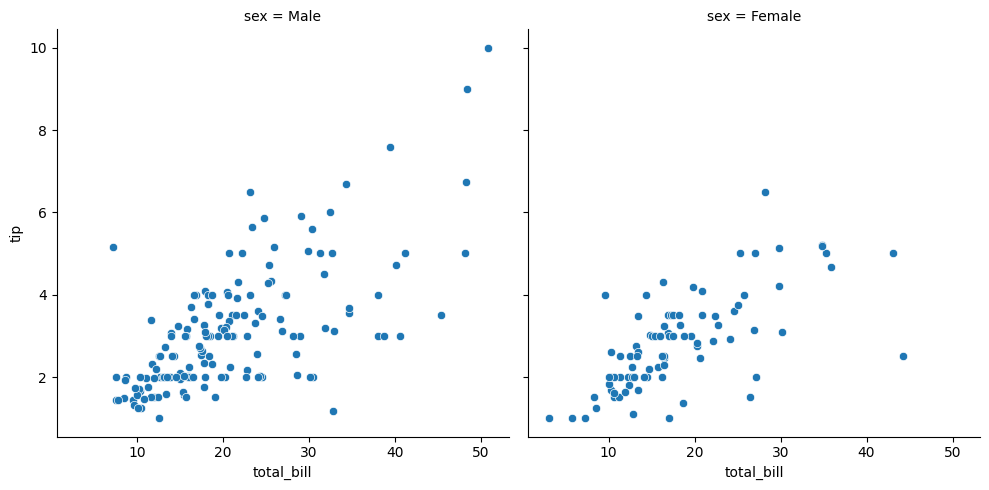

In [94]:
#facet plot
# Purpose:
# Creates multiple subplots by dividing the dataset based on one
# or more categorical variables, allowing easy comparison between groups.

# Best Used For:
# - Comparing the same visualization across categories
# - Identifying patterns within different groups
# - Exploring relationships in subsets of the data
# - Multi-panel exploratory data analysis (EDA)
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex')

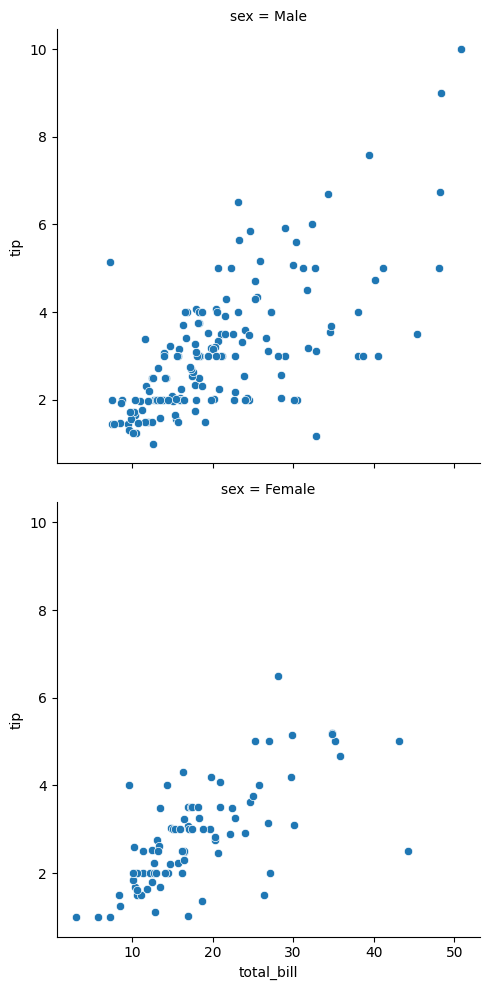

In [95]:
#row
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',row='sex')

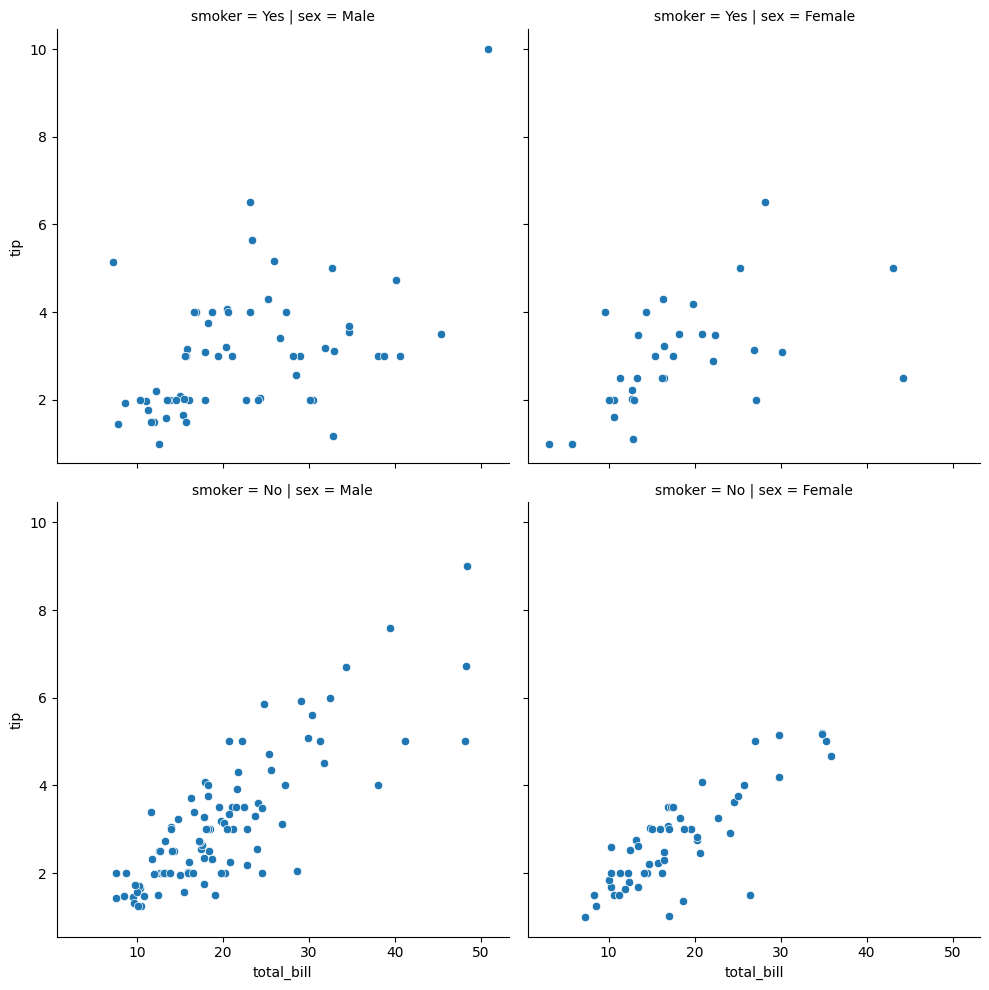

In [96]:
#graph drwan using both col and row parameter
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex',row='smoker')

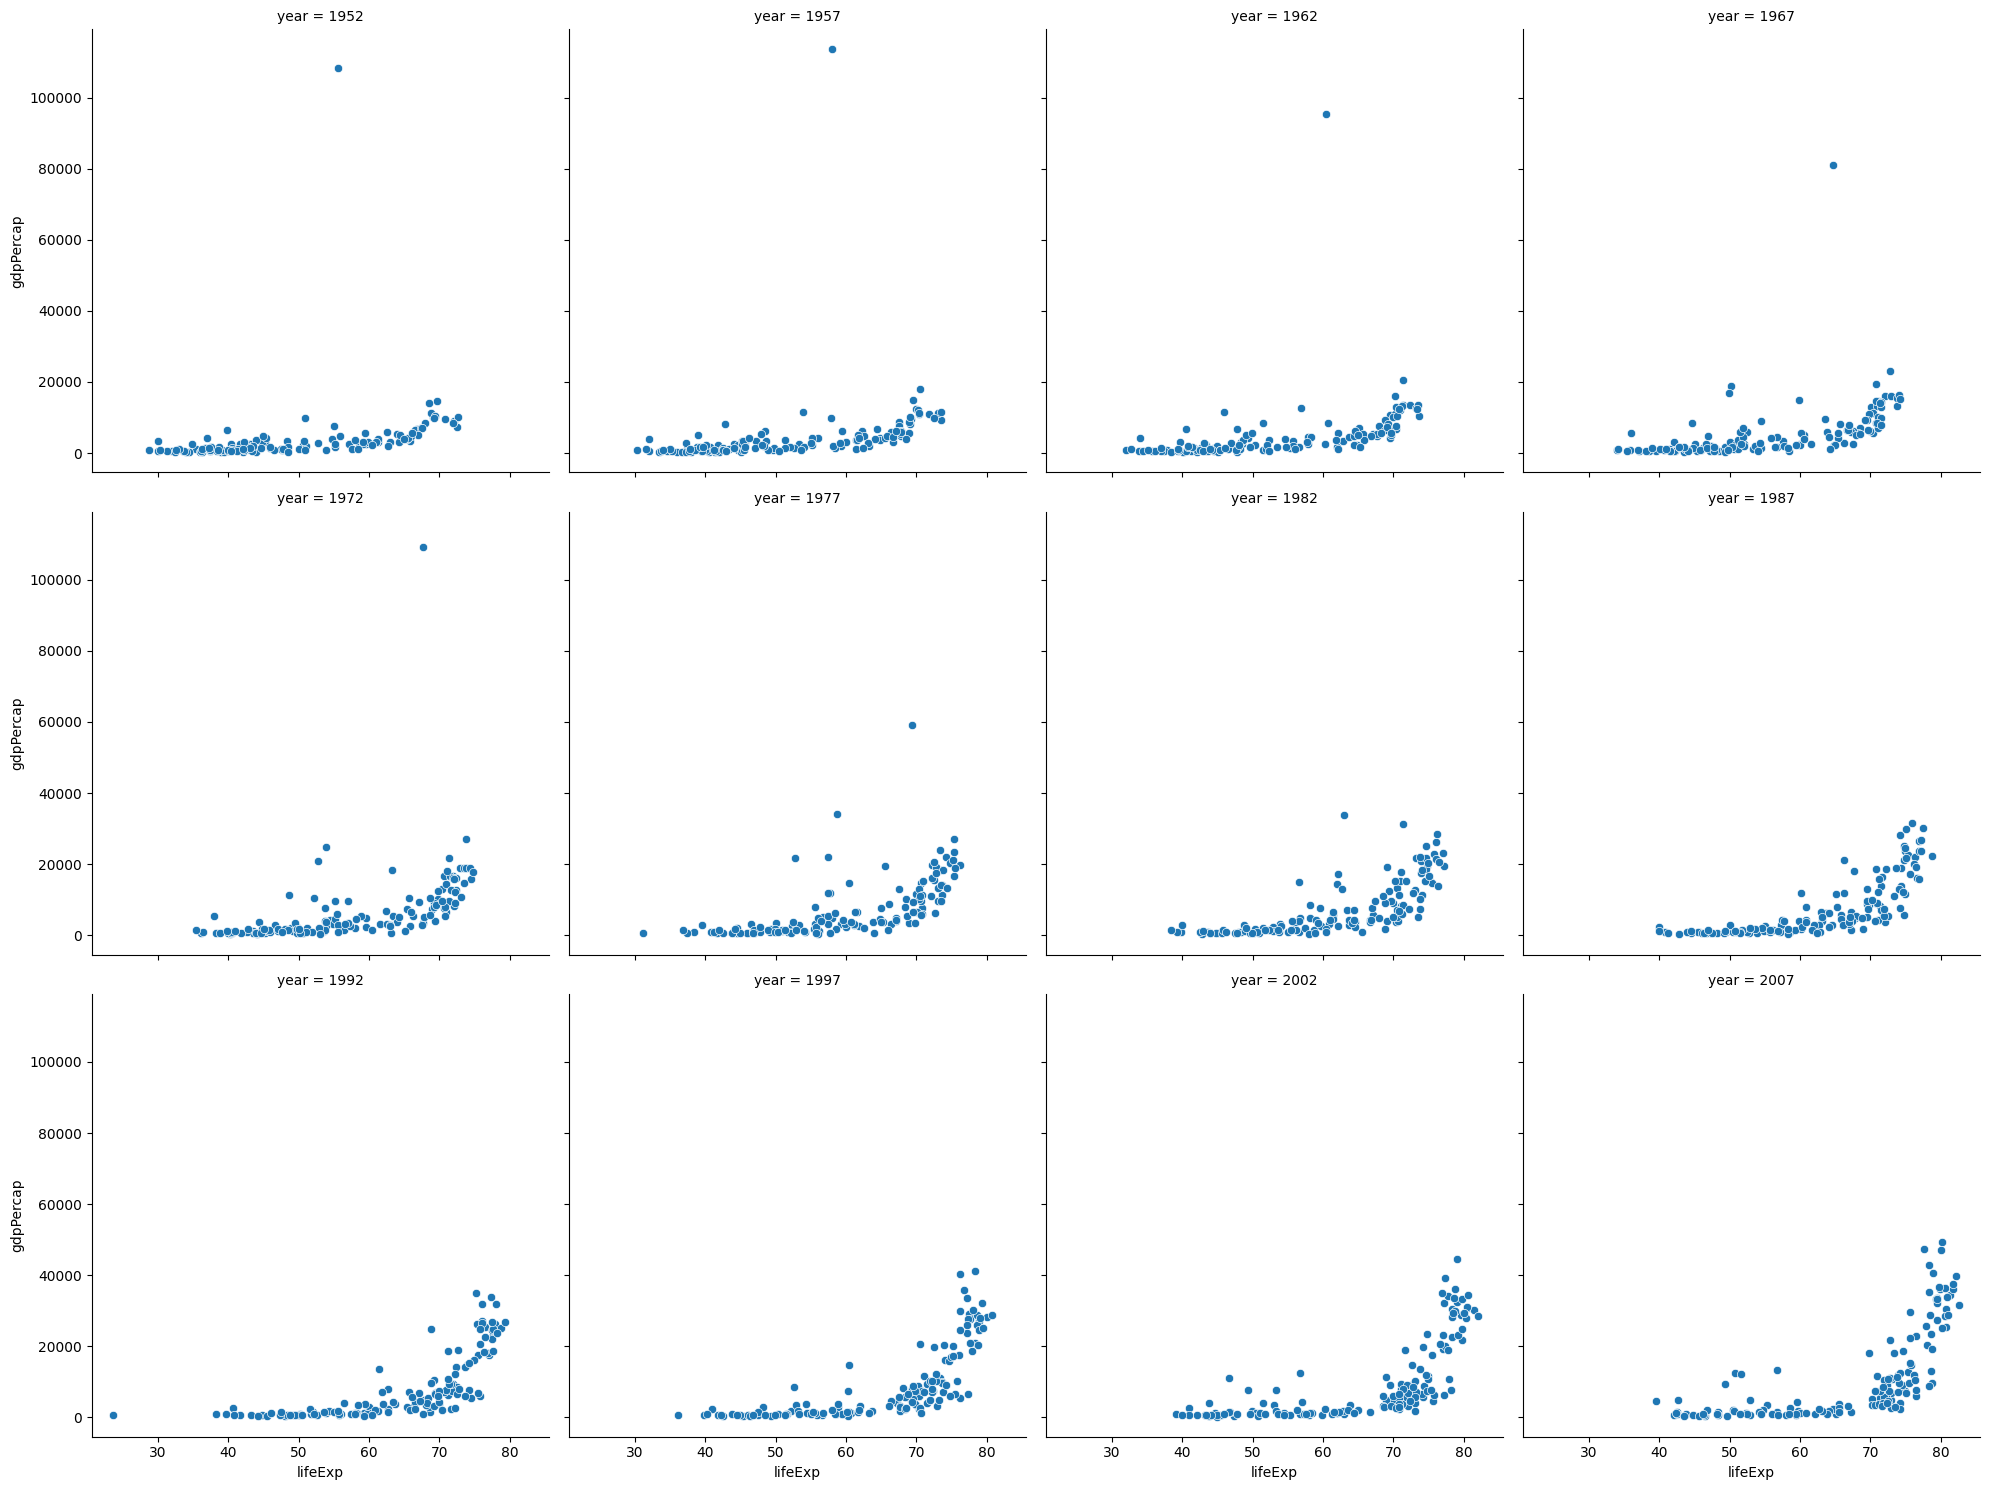

In [97]:
#col wrap
# Purpose:
# Limits the number of facet columns displayed in a single row.
#here in single row only 4 plots can be shown
sns.relplot(kind='scatter',data=gap,x='lifeExp',y='gdpPercap',col='year',col_wrap=4)

**Distribution Plots**

- Histogram
- KDE Plot
- Rug Plot
- Bivariate Histogram
- Bivariate Kde Plot
- Displot-Figure level function





<Axes: xlabel='total_bill', ylabel='Count'>

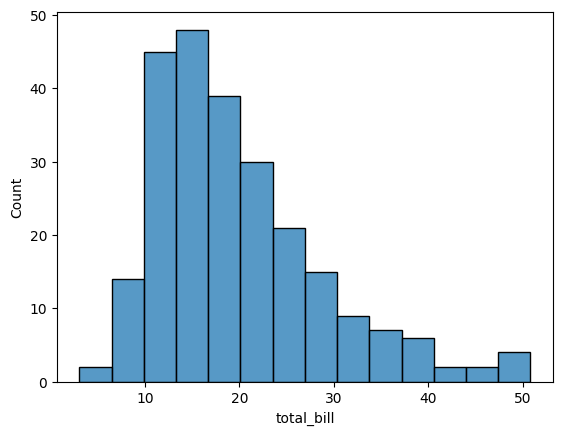

In [98]:
# univariate histogram
# Purpose:
# Displays the distribution of a single numerical variable by grouping
# data into intervals (bins) and showing the frequency of observations
# in each interval.

# Best Used For:
# - Understanding the distribution of data
# - Identifying the most common value ranges
# - Detecting skewness (left or right)
# - Identifying outliers
# - Checking whether data is approximately normally distributed

# Insight:
# Most customers have a total bill between $10 and $20, indicating that
# this is the most common spending range. As the total bill increases,
# the number of customers decreases, suggesting that high-value bills are
# less frequent. The distribution is right-skewed, with a few customers
# having exceptionally high total bills.

sns.histplot(data=tips, x='total_bill')

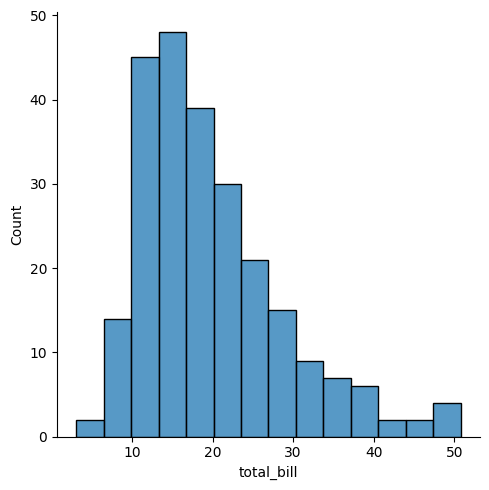

In [99]:
#same analysis is done using displot -Figure level function
sns.displot(data=tips, x='total_bill',kind='hist')

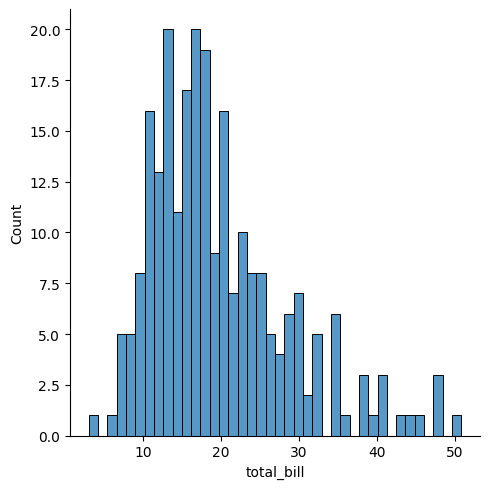

In [100]:
#bins
# Purpose:
# Divides the numerical data into equal intervals (called bins)
# and counts how many observations fall into each interval.
sns.displot(data=tips, x='total_bill',kind='hist',bins=40)

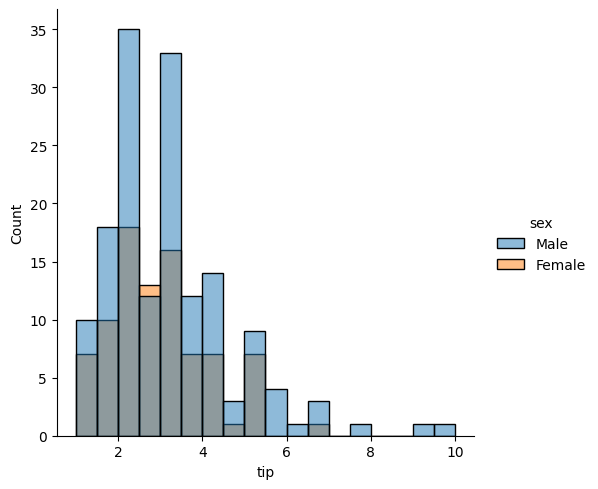

In [101]:
#hue
sns.displot(data=tips, x='tip',kind='hist',hue='sex')

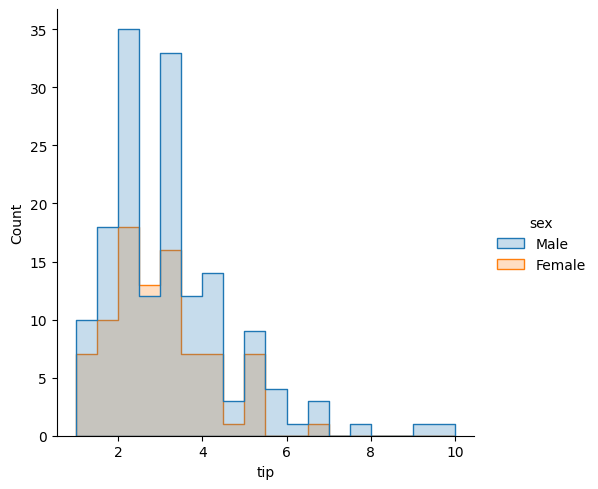

In [102]:
#element
# Purpose:
# Controls the visual style used to draw the histogram bars.
sns.displot(data=tips, x='tip',kind='hist',hue='sex',element='step')

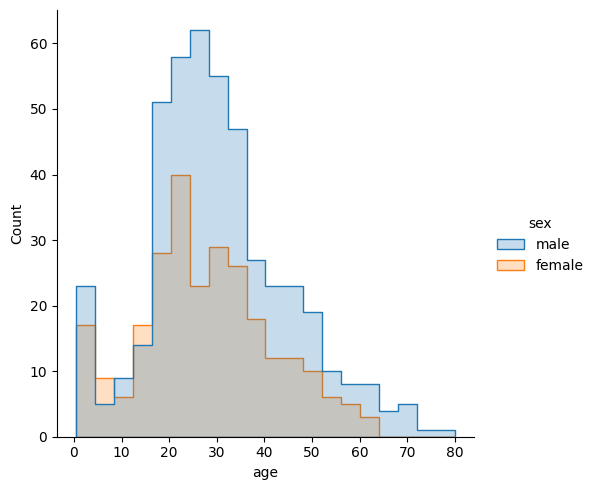

In [103]:
#plotting histogram for titanic dataset
# Insight:
# Both male and female passengers are primarily between 20 and 40 years old.
# Male passengers appear to be more numerous in most age groups, while the
# step outline clearly highlights the differences in age distribution between
# the two genders.
sns.displot(data=titanic, x='age',kind='hist',element='step',hue='sex')

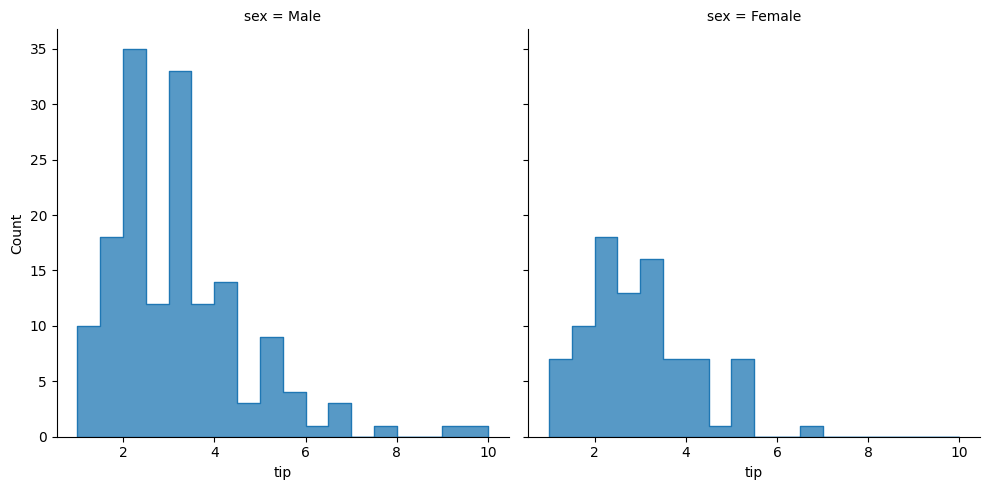

In [104]:
#faceting using col and row
sns.displot(data=tips, x='tip',kind='hist',col='sex',element='step')

<Axes: xlabel='total_bill', ylabel='Density'>

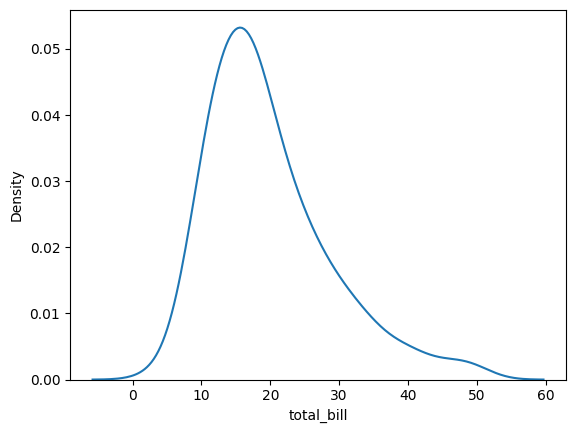

In [105]:
#kdeplot
# Purpose:
# Displays the distribution of a numerical variable using a
# smooth density curve instead of bars.

# Best Used For:
# - Understanding the distribution of data
# - Identifying peaks (modes) in the data
# - Comparing distributions across categories
# - Detecting skewness and spread
# - Visualizing the overall shape of the distribution

# Insight:
# The KDE curve shows that most total bill values are concentrated
# in the lower to middle range, with the density gradually decreasing
# as the bill amount increases. The distribution is right-skewed,
# indicating that very high total bills are relatively uncommon.
sns.kdeplot(data=tips,x='total_bill')

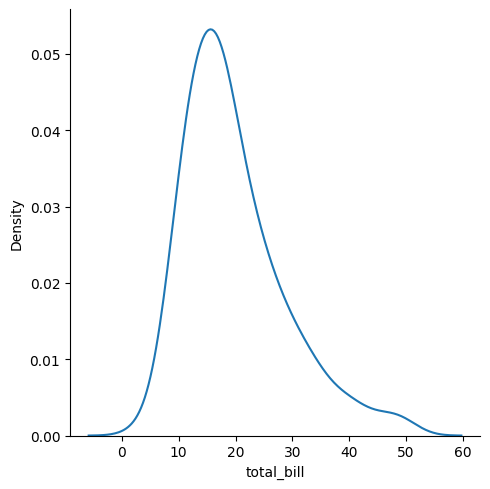

In [106]:
#same analysis using displot figure level function
sns.displot(kind='kde',data=tips,x='total_bill')

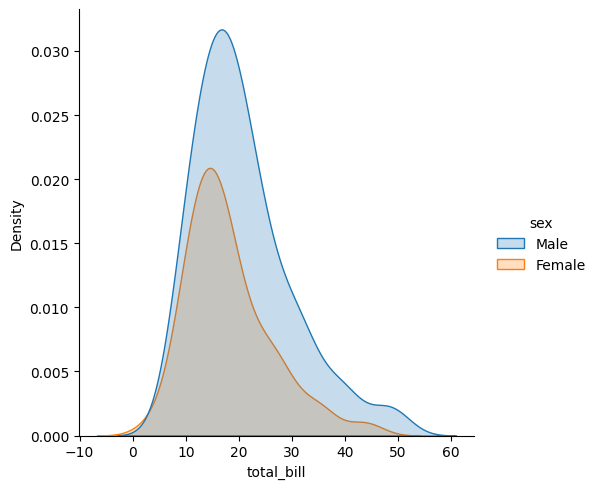

In [107]:
#fill
# Purpose:
# Fills the area under the KDE curve with color, making the
# distribution easier to visualize.

# Insight:
# The KDE plot compares the distribution of total bills for male and female
# customers using separate density curves. Most total bill values for both
# groups are concentrated in the lower to middle range, while higher bill
# amounts occur less frequently. The overlapping curves make it easy to
# compare differences in the distribution, spread, and peak density between
# male and female customers.

sns.displot(kind='kde',data=tips,x='total_bill',hue='sex',fill=True)

In [108]:
#Rugplot
# Purpose:
# Displays each individual data point as a small tick mark
# along an axis, showing the exact distribution of observations.

# Best Used For:
# - Visualizing individual observations
# - Identifying clusters of data points
# - Detecting gaps in the data
# - Complementing histograms or KDE plots

# Insight:
# The rug plot shows the exact position of each total bill value.
# Most tick marks are concentrated in the lower to middle bill range,
# indicating that most customers have relatively lower total bills.
# Fewer tick marks at higher bill values suggest that expensive bills
# are less common.


<Axes: xlabel='total_bill', ylabel='Density'>

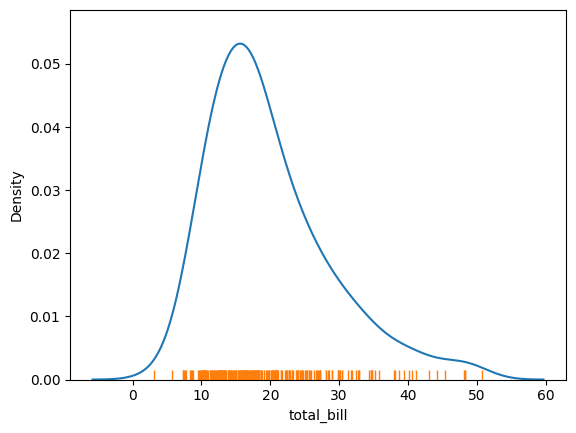

In [109]:
sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

<Axes: xlabel='total_bill', ylabel='tip'>

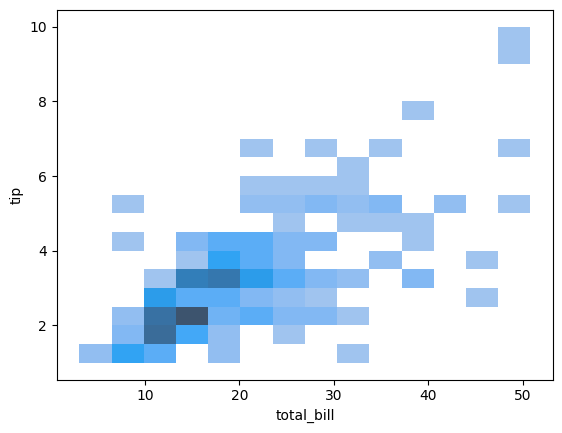

In [110]:
#Bivariate Histogram
# Purpose:
# Displays the relationship between two numerical variables by
# grouping observations into two-dimensional bins and showing
# their frequency using color intensity.

# Best Used For:
# - Exploring relationships between two numerical variables
# - Identifying areas with high data concentration
# - Detecting clusters and patterns
# - Identifying sparse regions in the data

# Insight:
# The plot shows that the highest concentration of observations
# occurs where total bills are relatively low to moderate and
# tips are also moderate. As the total bill increases, the number
# of observations decreases. The pattern suggests a positive
# relationship, indicating that customers who spend more generally
# tend to leave higher tips.
sns.histplot(data=tips,x='total_bill',y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

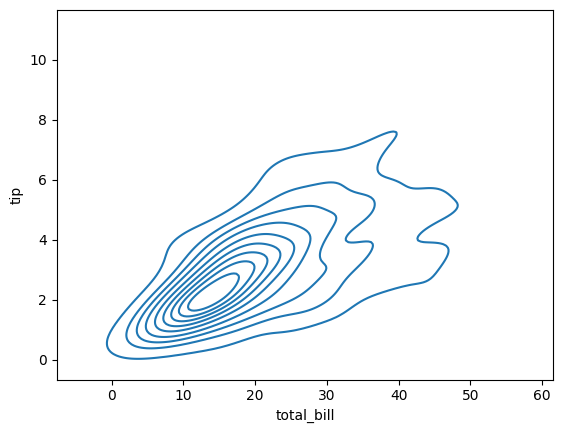

In [111]:
#Bivariate kDE plot
# Purpose:
# Displays the relationship between two numerical variables
# using contour lines (or filled contours) to represent the
# density of observations.

# Best Used For:
# - Identifying regions with high data density
# - Exploring relationships between two numerical variables
# - Detecting clusters and patterns
# - Visualizing distributions without individual data points

# Insight:
# The highest density of observations is concentrated where
# total bills are low to moderate and tips are also relatively low.
# The density gradually decreases as both total bill and tip increase,
# indicating fewer observations at higher values. The upward-sloping
# density contours suggest a positive relationship, meaning customers
# with higher total bills generally tend to leave higher tips.
sns.kdeplot(data=tips,x='total_bill',y='tip')

**Matrix Plots**


- Heatmap
- Clustermap



<Axes: xlabel='year', ylabel='country'>

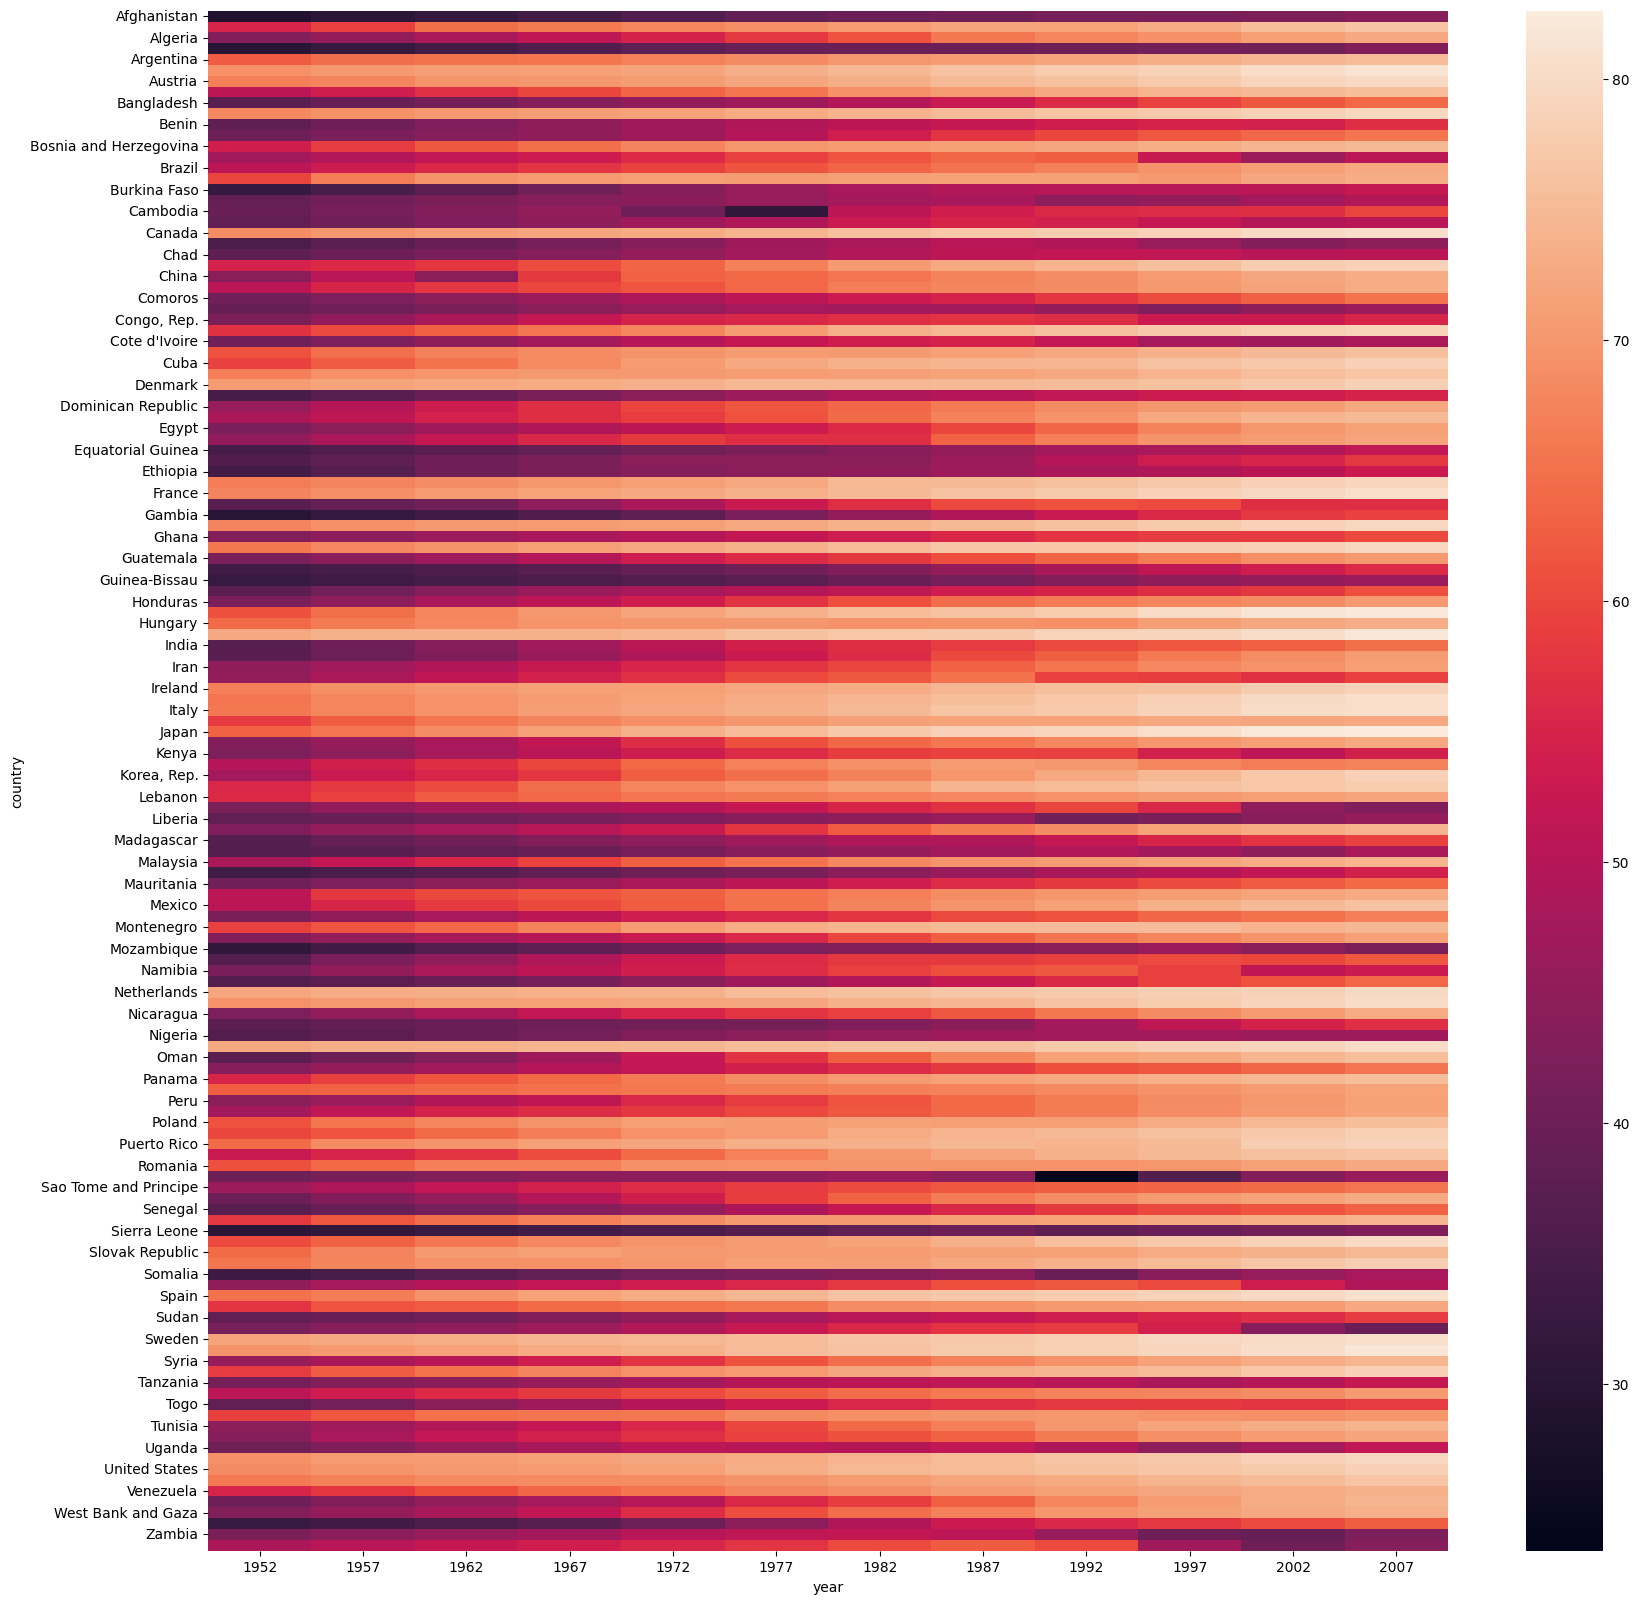

In [112]:
#Heatmap
# Purpose:
# Visualizes values in a matrix using color intensity, making
# it easy to identify patterns, trends, and variations across
# two dimensions.

# Best Used For:
# - Comparing values across two categorical variables
# - Identifying patterns and trends
# - Detecting high and low values
# - Visualizing pivot tables and correlation matrices

# Insight:
# The heatmap compares life expectancy across different countries
# and years. Darker and lighter colors represent lower and higher
# life expectancy values, making it easy to identify countries with
# consistently high or low life expectancy as well as changes over
# time. Similar color patterns across a row indicate stable life
# expectancy, while noticeable color changes suggest significant
# improvements or declines over the years.

grid=gap.pivot_table(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(20,20))
sns.heatmap(grid)

<Axes: xlabel='year', ylabel='country'>

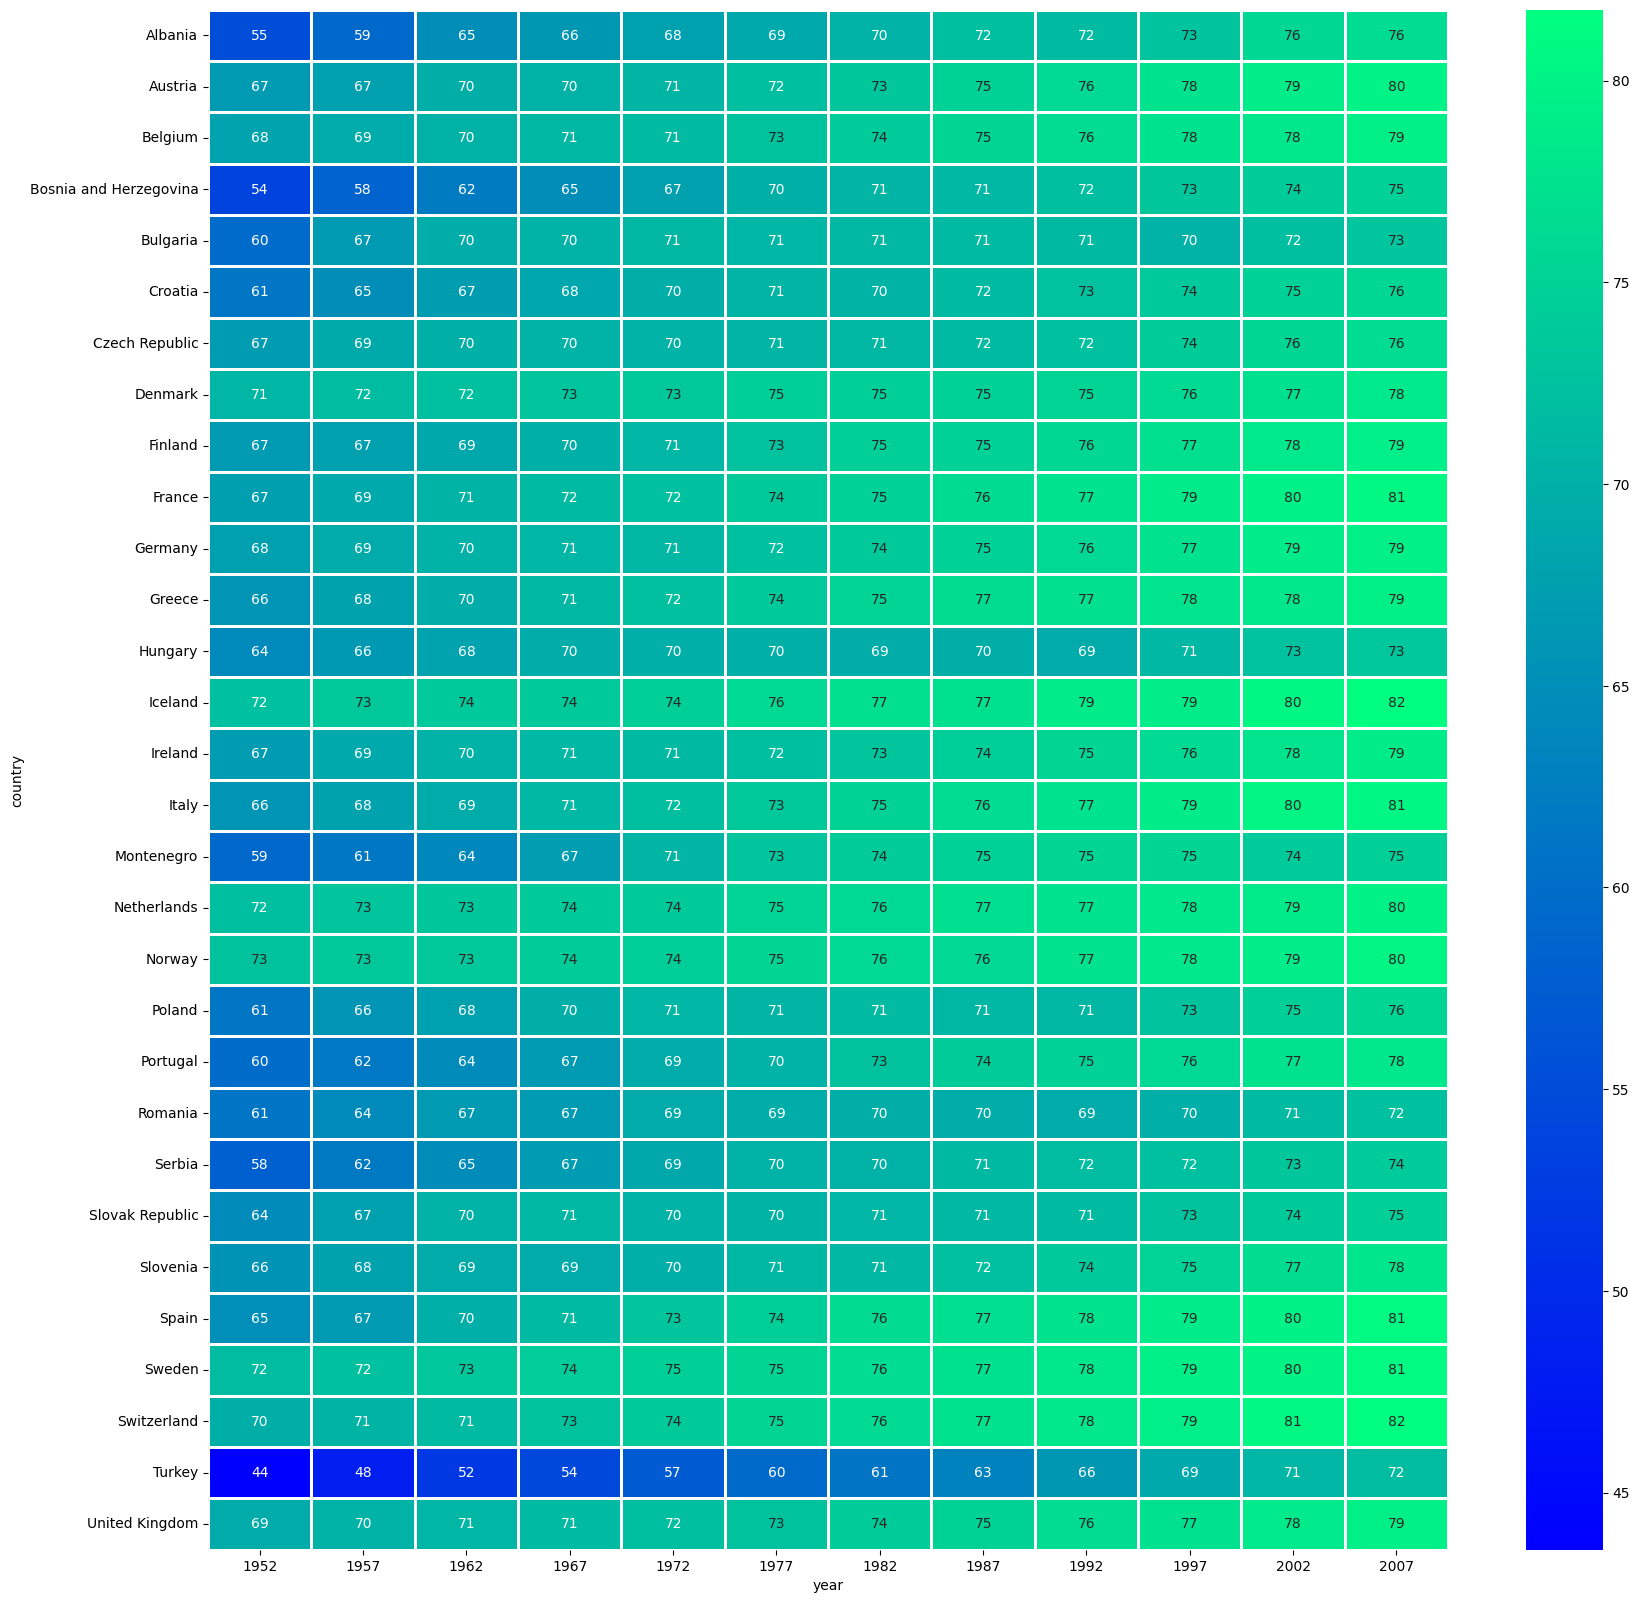

In [113]:
#annot
# Purpose:
# Displays the actual data values inside each cell of the heatmap.

#Insights
#same analysis id done like above but for the continent Europe rather than
# all continents
df=gap[gap.continent=='Europe'].pivot_table(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(20,20))
sns.heatmap(df,annot=True,cmap='winter',linewidths=0.8)

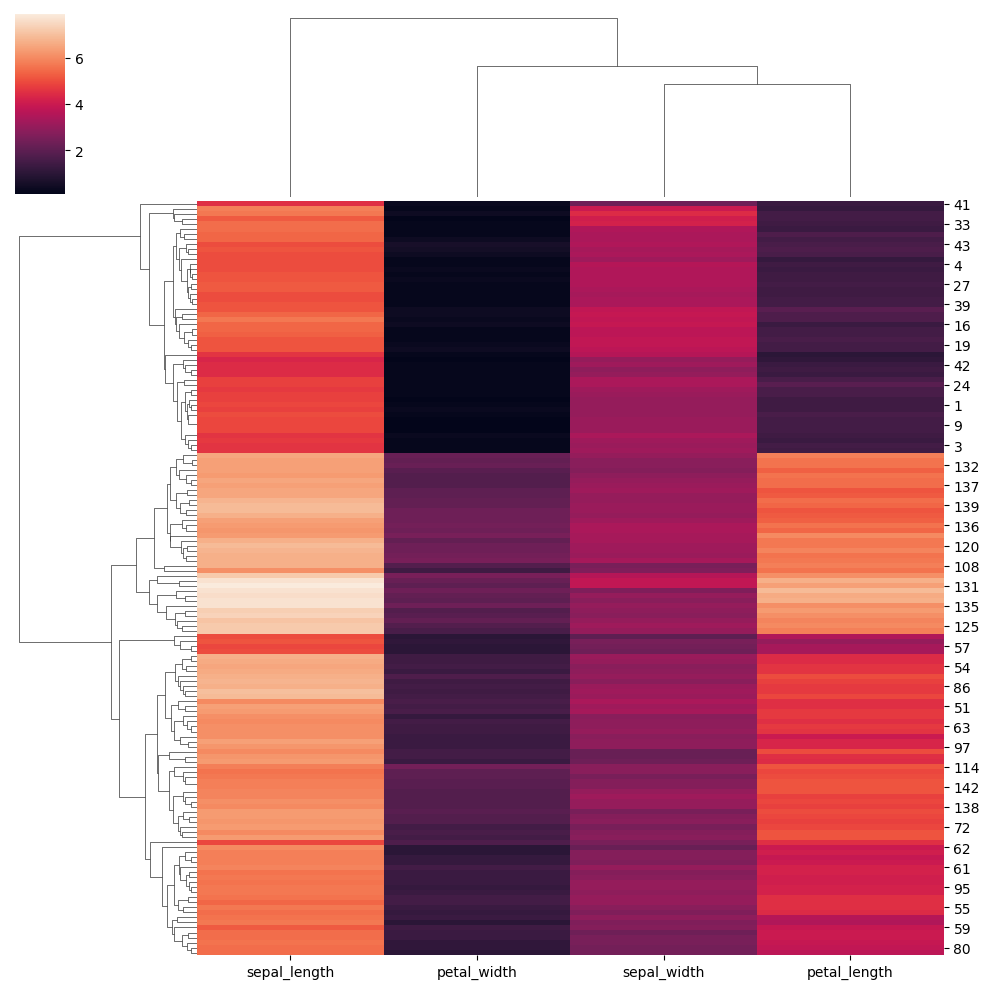

In [114]:
#Cluster map
# Purpose:
# Visualizes a heatmap while automatically grouping similar
# rows and columns using hierarchical clustering.

# Best Used For:
# - Identifying similar groups or clusters
# - Finding hidden patterns in data
# - Gene expression analysis
# - Customer segmentation
# - Comparing similarities between observations

# Insight:
# The clustermap groups iris flowers with similar sepal and petal
# measurements together. Flowers with similar characteristics are
# placed close to each other, while those with different measurements
# are placed in separate clusters. The dendrograms help visualize the
# similarity between observations and features, making it easier to
# identify natural groupings in the dataset.

sns.clustermap(iris.iloc[:,[0,1,2,3]])


**Categorical** **plot**


- Stip Plot
- Swarm Plot
- Box Plot
- Violin Plot
- Bar Plot
- Point Plot
- Count Plot
- Cat plot-Figure level function




<Axes: xlabel='day', ylabel='total_bill'>

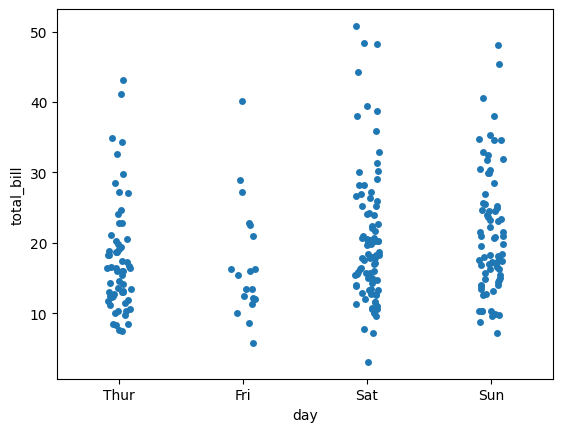

In [115]:
#Strip plot
# Purpose:
# Displays individual observations for a numerical variable
# across one or more categorical variables.

# Best Used For:
# - Visualizing individual data points
# - Comparing distributions across categories
# - Detecting clusters and outliers
# - Small to medium-sized datasets

# Insight:
# The strip plot shows the distribution of individual total bill values
# across each day of the week. It highlights the spread of bills, making
# it easy to identify variations, clusters, and potential outliers for
# each day. Most bills are concentrated at lower values, while a few
# higher-value bills appear as isolated points.

sns.stripplot(data=tips,x='day',y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

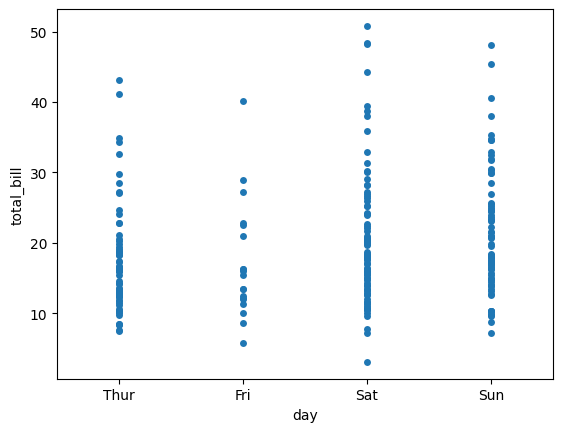

In [116]:
#Jitter
# Purpose:
# Adds a small amount of random horizontal displacement to the points
# to reduce overlap and make individual observations easier to see.
sns.stripplot(data=tips,x='day',y='total_bill',jitter=False)

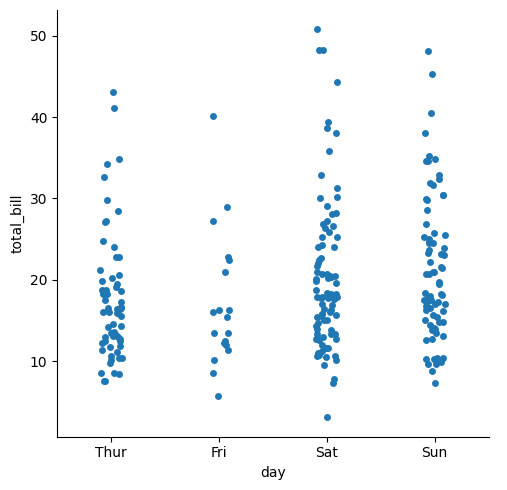

In [117]:
#using catplot Figure level Function
sns.catplot(data=tips,x='day',y='total_bill',kind='strip')

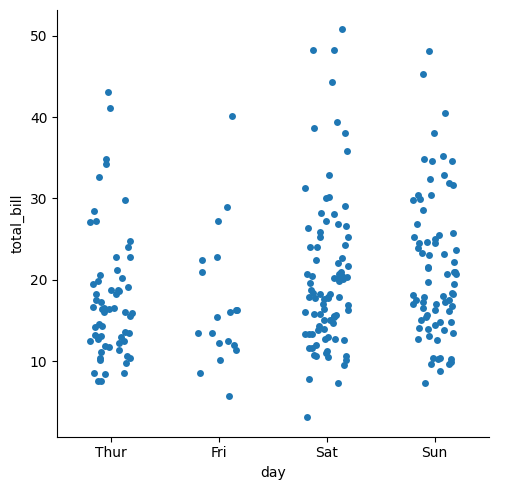

In [118]:
#catoplot with jitter paramter
sns.catplot(data=tips,x='day',y='total_bill',kind='strip',jitter=0.2)

<Axes: xlabel='day', ylabel='total_bill'>

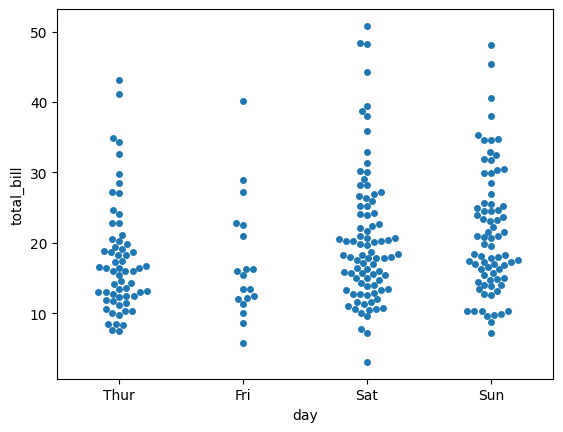

In [119]:
#Swarmplot
# Purpose:
# Displays individual observations across categories while
# automatically adjusting point positions to prevent overlap.

# Best Used For:
# - Comparing distributions across categories
# - Visualizing individual data points
# - Detecting clusters and outliers
# - Small to medium-sized datasets

# Insight:
# The swarm plot shows the distribution of total bill values
# across different days. Since the points do not overlap, it is
# easy to observe the density, spread, and exact distribution of
# bills for each day. Most bills are concentrated at lower to
# moderate values, while a few higher-value bills appear as
# isolated points, indicating potential high-spending customers.

sns.swarmplot(data=tips,x='day',y='total_bill')

<Axes: xlabel='sex', ylabel='total_bill'>

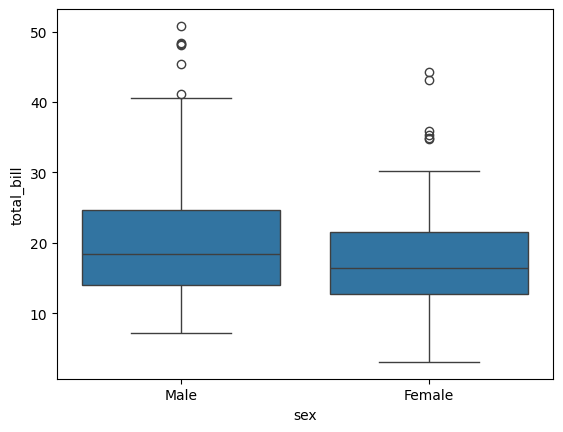

In [120]:
#Boxplot
# Purpose:
# Summarizes the distribution of a numerical variable across
# categories using the median, quartiles, spread, and outliers.

# Best Used For:
# - Comparing distributions across categories
# - Detecting outliers
# - Comparing medians and variability
# - Understanding data spread

# Insight:
# The box plot compares the distribution of total bill amounts
# for male and female customers. It shows the median, spread,
# and potential outliers for each group. Both groups exhibit a
# similar distribution, although male customers generally have
# a slightly higher median total bill and a wider spread.
# Several high-value bills appear as outliers in both categories.
sns.boxplot(data=tips,x='sex',y='total_bill')

<Axes: xlabel='sex', ylabel='total_bill'>

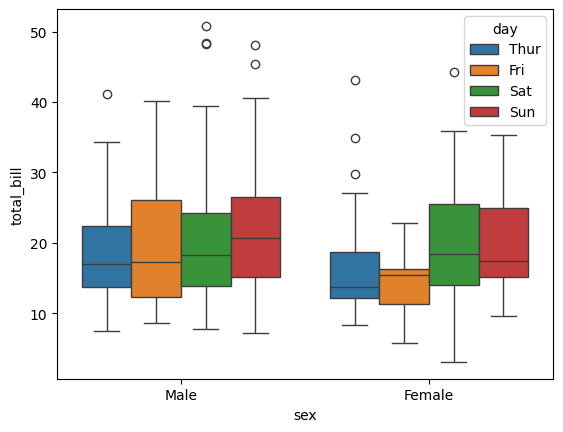

In [121]:
#hue
sns.boxplot(data=tips,x='sex',y='total_bill',hue='day')

<Axes: ylabel='total_bill'>

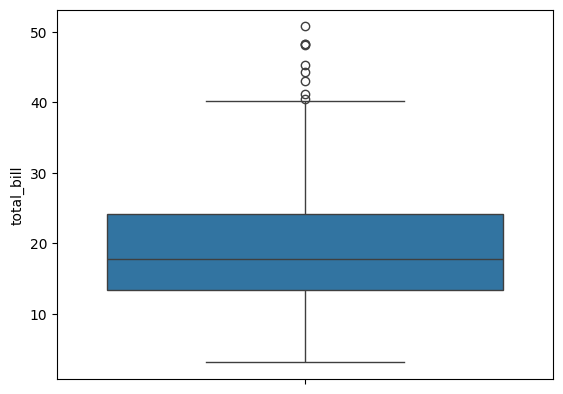

In [122]:
#Plotting boxplot on a single column
sns.boxplot(data=tips,y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

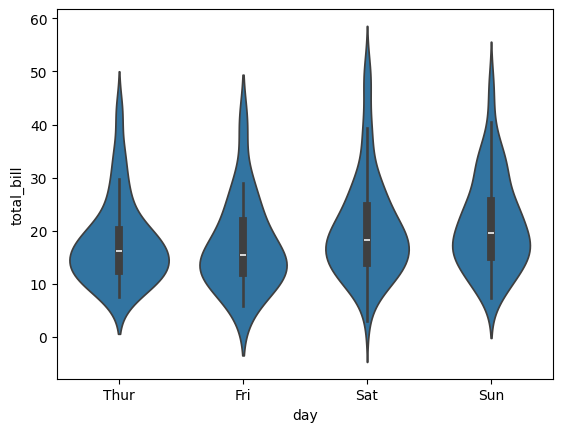

In [123]:
#Violin plot
# Purpose:
# Combines a box plot and a KDE plot to show the distribution,
# density, spread, and summary statistics of a numerical
# variable across different categories.

# Best Used For:
# - Comparing distributions across categories
# - Visualizing data density and spread
# - Identifying skewness and multiple peaks
# - Detecting differences in distribution shape

# Insight:
# The violin plot compares the distribution of total bill amounts
# across different days. The width of each violin indicates where
# the data is most concentrated—wider sections represent bill
# amounts that occur more frequently, while narrower sections
# represent less common values. It also reveals the spread,
# skewness, and overall distribution shape, making it easier to
# compare customer spending patterns across different days.
sns.violinplot(data=tips,x='day',y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

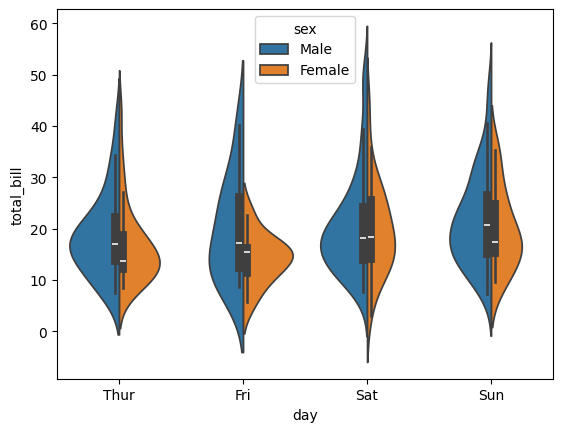

In [124]:
#hue paramter with split paramter
sns.violinplot(data=tips,x='day',y='total_bill',hue='sex',split=True)

<Axes: xlabel='sex', ylabel='total_bill'>

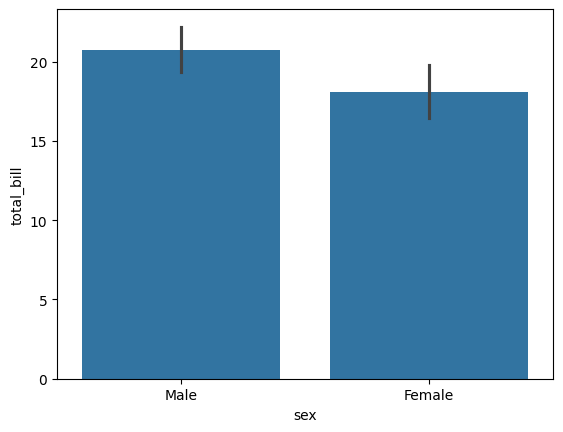

In [125]:
#Bar plot
# Purpose:
# Compares the average value of a numerical variable across
# different categories. By default, it displays the mean along
# with confidence intervals (error bars).

# Best Used For:
# - Comparing average values across categories
# - Identifying differences between groups
# - Summarizing numerical data by category
# - Visualizing aggregated statistics

# Insight:
# The bar plot compares the average total bill for male and
# female customers. Male customers have a slightly higher
# average total bill than female customers. The error bars
# indicate the variability (confidence interval) around the
# estimated mean, helping assess the reliability of the
# comparison.
sns.barplot(data=tips,x='sex',y='total_bill')

<Axes: xlabel='sex', ylabel='total_bill'>

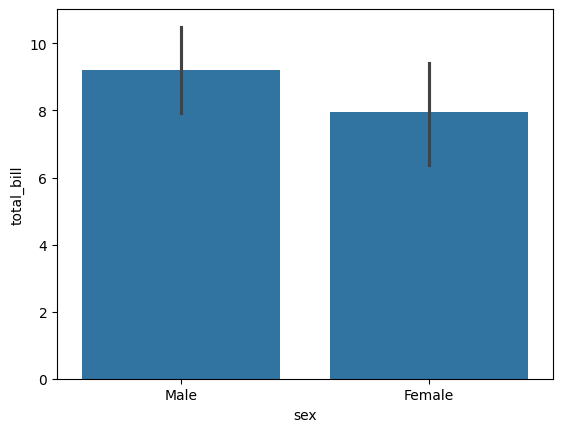

In [126]:
#estimator
# Purpose:
# Specifies the statistical function used to calculate the
# value represented by each bar.
sns.barplot(data=tips,x='sex',y='total_bill',estimator=np.std)

<Axes: xlabel='sex', ylabel='total_bill'>

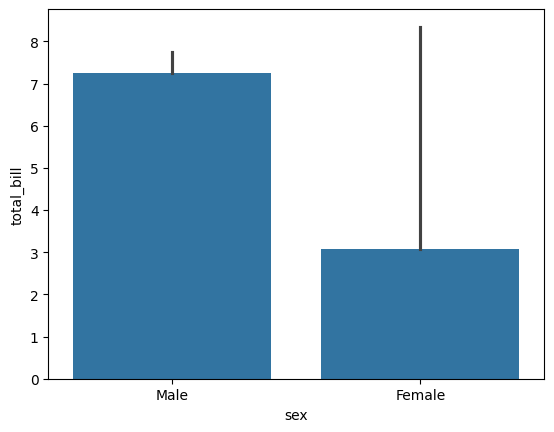

In [127]:
sns.barplot(data=tips,x='sex',y='total_bill',estimator=np.min)

<Axes: xlabel='sex', ylabel='total_bill'>

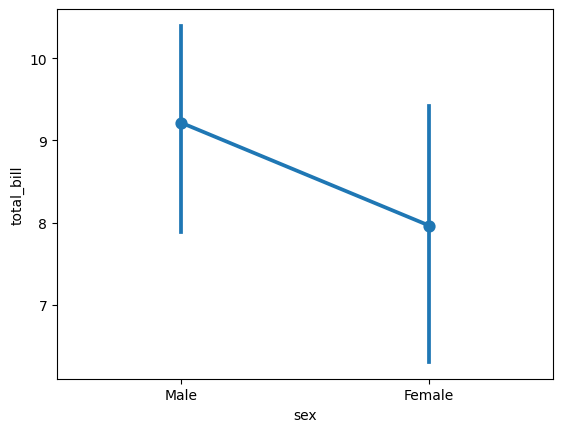

In [128]:
#Pointplot
# Purpose:
# Displays summary statistics for a numerical variable across
# categories using points connected by lines. It is useful for
# comparing values and observing trends between categories.

# Best Used For:
# - Comparing summary statistics across categories
# - Identifying trends between groups
# - Comparing means, medians, standard deviations, etc.
# - Visualizing changes across ordered categories

# Insight:
# The point plot compares the standard deviation of total bill
# amounts for male and female customers. A higher point indicates
# greater variability in total bills for that group, while a lower
# point indicates that the bill amounts are more consistent.
# This helps compare the spread of spending between the two genders.
sns.pointplot(data=tips,x='sex',y='total_bill',estimator=np.std)

<Axes: xlabel='sex', ylabel='count'>

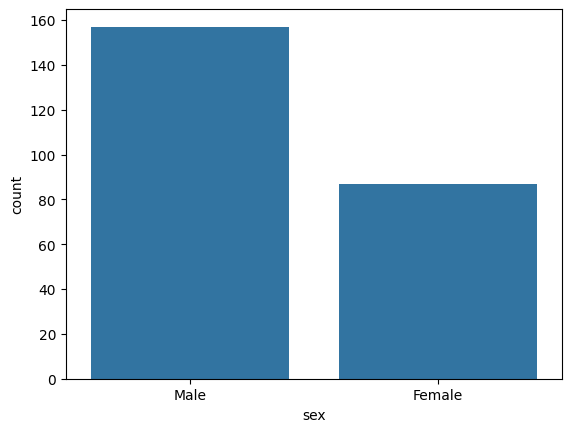

In [129]:
#Countplot
# Purpose:
# Displays the frequency (count) of observations in each
# category.

# Best Used For:
# - Comparing category frequencies
# - Visualizing class distribution
# - Identifying imbalanced data
# - Counting occurrences of categorical values

# Insight:
# The count plot shows the number of male and female customers
# in the dataset. Male customers appear more frequently than
# female customers, indicating that the dataset contains more
# observations for males than females.
sns.countplot(data=tips,x='sex')

**Regression Plots**


*   Reg Plot
*   Residual Plot
*   lm plot-Figure level Function







<Axes: xlabel='total_bill', ylabel='tip'>

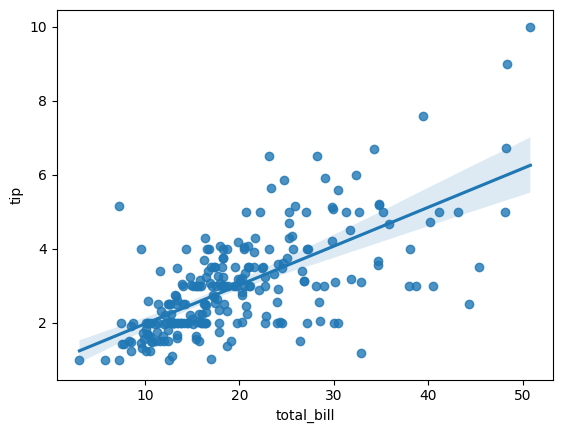

In [130]:
#Regplot
# Purpose:
# Displays the relationship between two numerical variables
# along with a fitted regression line to identify trends.

# Best Used For:
# - Exploring relationships between variables
# - Identifying positive or negative correlations
# - Visualizing linear trends
# - Predicting one variable from another

# Insight:
# The regression plot shows a positive linear relationship
# between the total bill and the tip amount. As the total bill
# increases, the tip generally increases as well. The regression
# line summarizes this trend, while the scatter points show the
# individual observations. The confidence interval around the
# line indicates the uncertainty of the estimated relationship.
sns.regplot(data=tips,x='total_bill',y='tip')

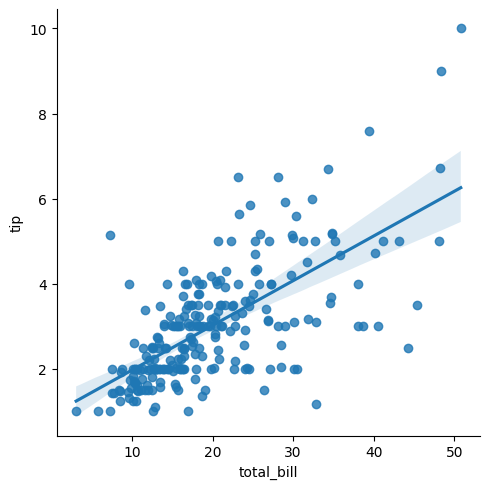

In [131]:
#lm plot -figure level function
sns.lmplot(data=tips,x='total_bill',y='tip')

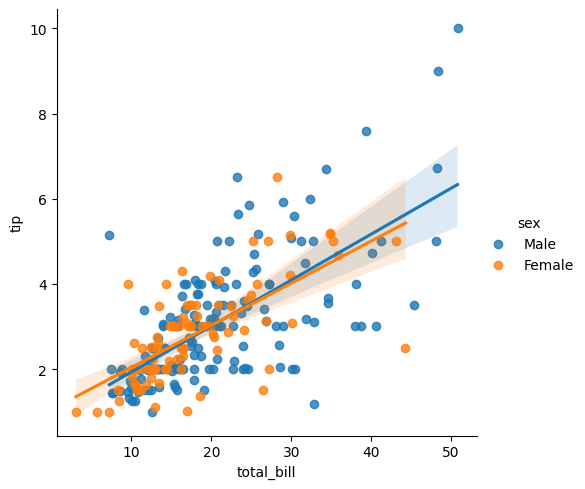

In [132]:
#lmplot with hue paramter
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

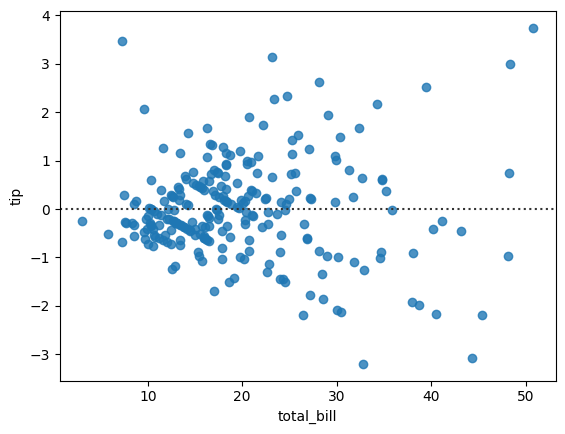

In [133]:
#Residplot
# Purpose:
# Displays the residuals (errors) of a regression model to
# evaluate how well the regression line fits the data.

# Best Used For:
# - Checking the quality of a linear regression model
# - Detecting non-linear relationships
# - Identifying outliers
# - Verifying regression assumptions

# Insight:
# The residual plot shows the difference between the actual
# tip values and the values predicted by the regression model.
# If the residuals are randomly scattered around the zero line,
# it indicates that a linear model is appropriate. Any visible
# pattern or curve suggests that the relationship may not be
# purely linear, while points far from the zero line may
# represent potential outliers.
sns.residplot(data=tips,x='total_bill',y='tip')

**FacteGrid**

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


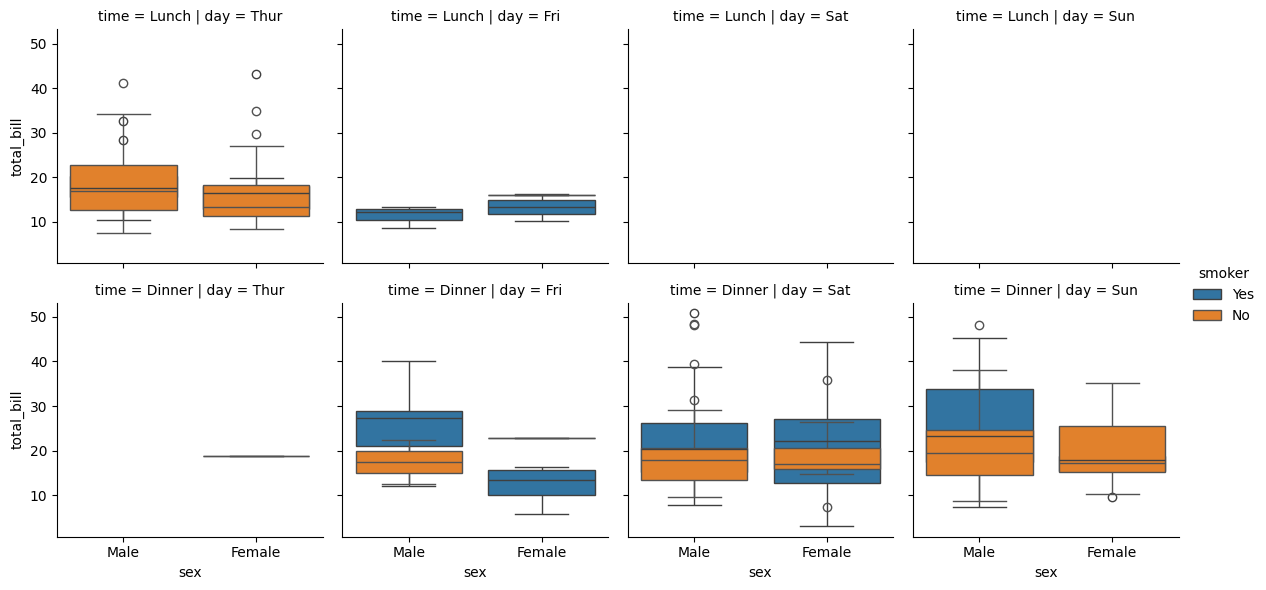

In [134]:
#Facetgrid
# Purpose:
# Creates a grid of plots by splitting the dataset based on one
# or more categorical variables, making it easy to compare
# patterns across multiple subsets.

# Best Used For:
# - Comparing distributions across multiple categories
# - Multi-dimensional data visualization
# - Finding interactions between categorical variables
# - Creating small multiple plots

# Insight:
# The FacetGrid creates separate box plots for each combination
# of day (columns) and time (rows), while smoker status is shown
# using different colors. This allows easy comparison of total
# bill distributions between males and females across different
# days, meal times, and smoking status. It helps identify how
# customer spending patterns vary across these multiple categories.
g=sns.FacetGrid(data=tips,col='day',row='time',hue='smoker')
g.map(sns.boxplot,'sex','total_bill')
g.add_legend()

**MultiPlots**


*   Pair Plot
*   Pair Grid
*   Joint Plot
*   Joint Grid





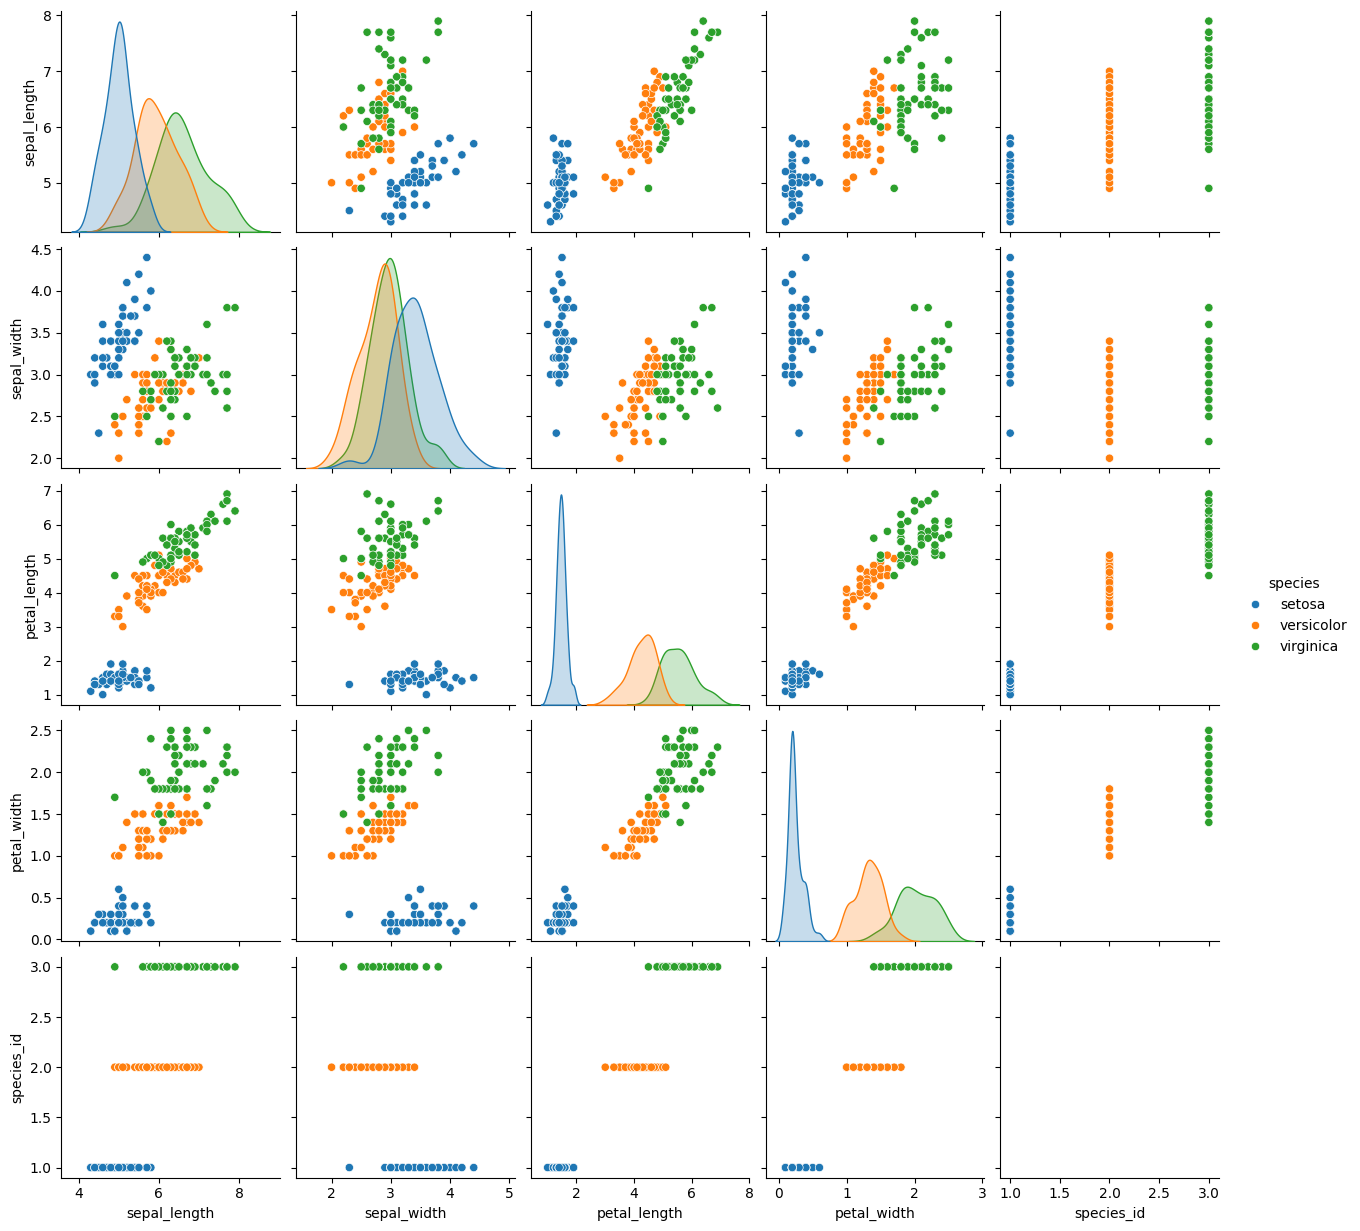

In [135]:
#Pairplot
# Purpose:
# Displays pairwise relationships between numerical variables
# and their individual distributions in a single grid.

# Best Used For:
# - Exploring relationships between multiple variables
# - Detecting correlations
# - Identifying clusters and patterns
# - Comparing different classes
# - Exploratory Data Analysis (EDA)

# Insight:
# The pair plot compares all numerical features of the Iris
# dataset while distinguishing species using different colors.
# It reveals strong relationships between petal length and
# petal width, making the species easier to separate. Setosa
# forms a clearly distinct cluster, while Versicolor and
# Virginica show some overlap but are still reasonably
# distinguishable based on petal measurements.
sns.pairplot(iris,hue='species')

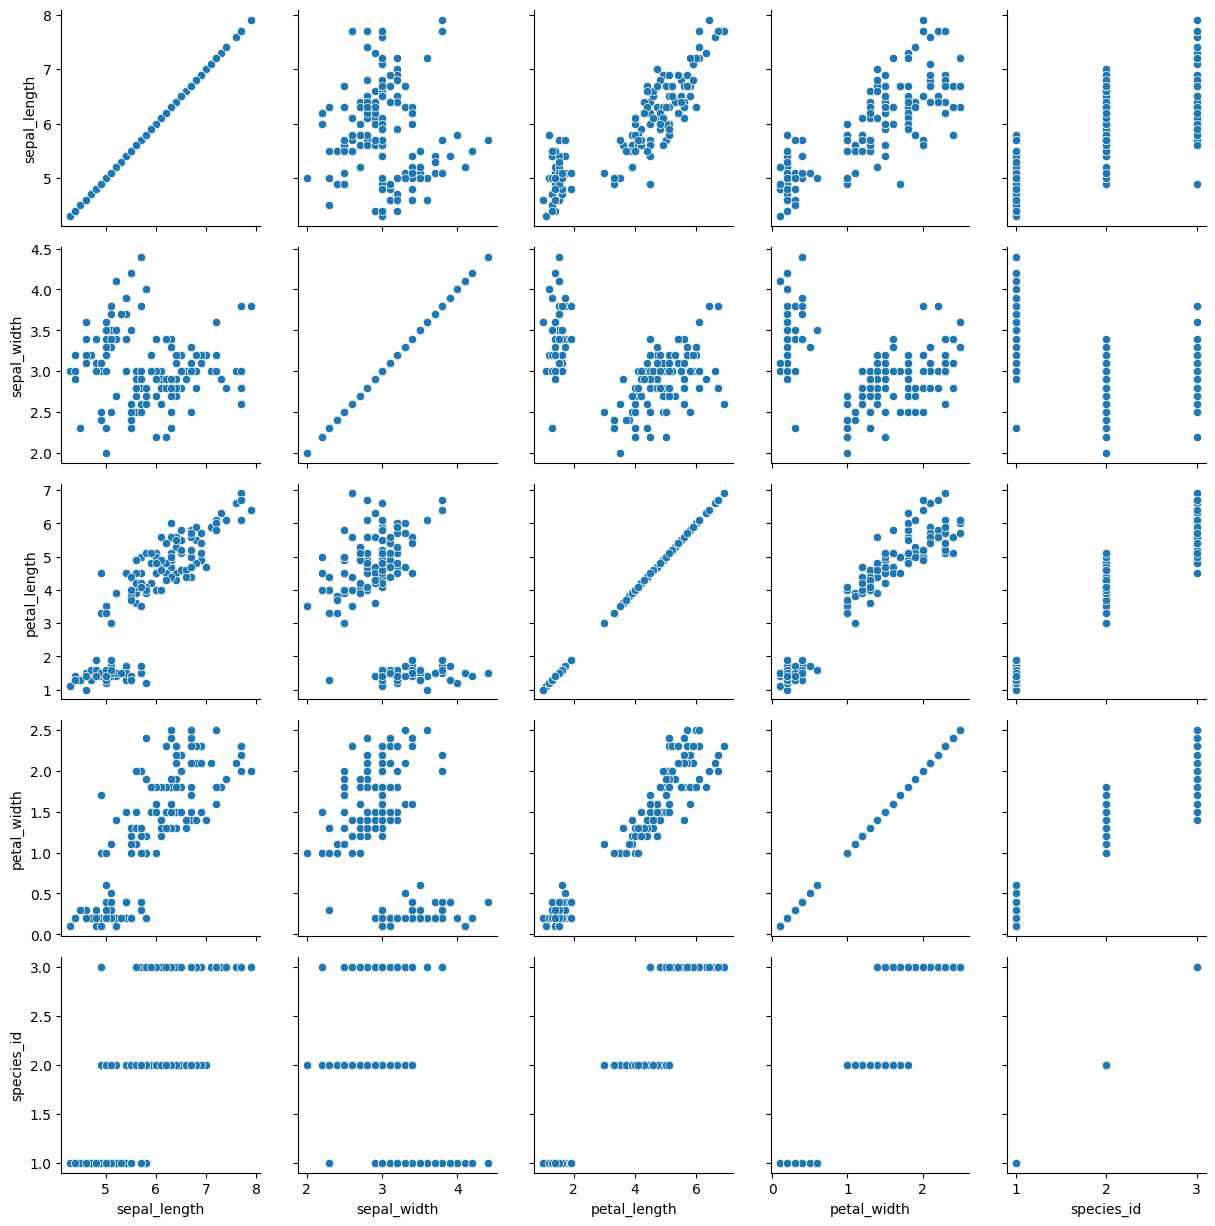

In [136]:
#Parigrid
# Purpose:
# Creates a customizable grid of pairwise relationships between
# numerical variables, allowing different plot types for the
# upper triangle, lower triangle, and diagonal.

# Best Used For:
# - Exploring relationships between multiple variables
# - Creating customized pairwise visualizations
# - Comparing different plot types in one grid
# - Advanced Exploratory Data Analysis (EDA)

# Insight:
# The PairGrid displays scatter plots for every pair of numerical
# features in the Iris dataset. It helps identify relationships,
# clusters, correlations, and potential outliers between feature
# pairs. Similar observations form visible clusters, while strong
# positive relationships can be observed between some features,
# such as petal length and petal width.
g=sns.PairGrid(data=iris)
g.map(sns.scatterplot)

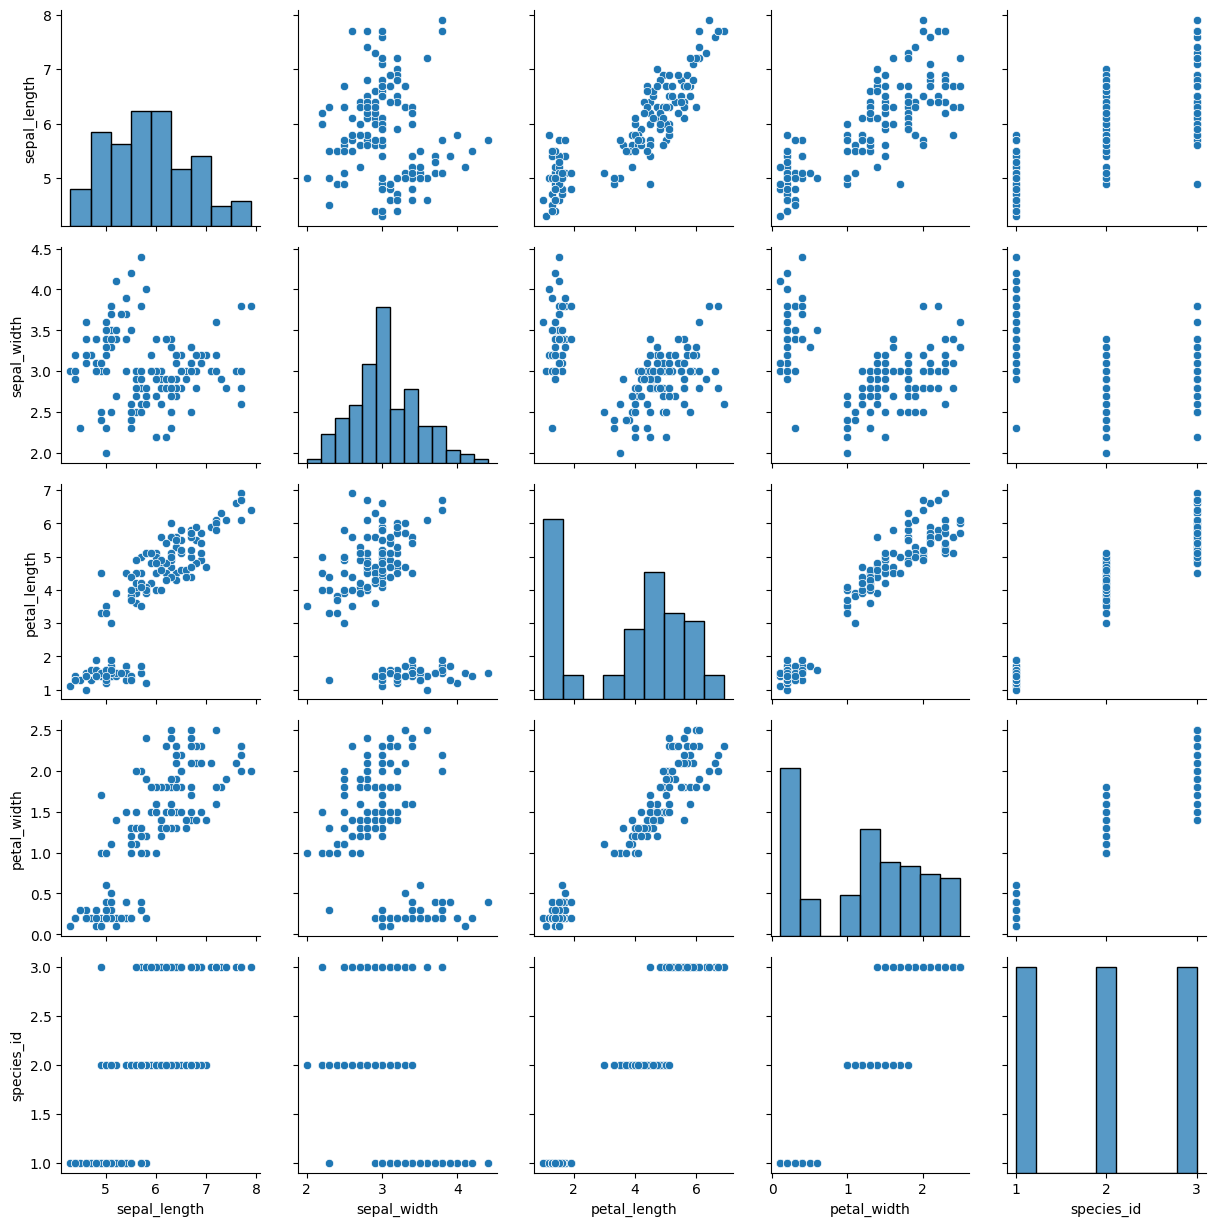

In [137]:
# map_diag()
# Purpose:
# Applies a plotting function only to the diagonal plots
# (where a variable is plotted against itself).

# map_offdiag()
# Purpose:
# Applies a plotting function to all off-diagonal plots
# (where one variable is plotted against another).
g=sns.PairGrid(data=iris)
g.map_offdiag(sns.scatterplot)
g.map_diag(sns.histplot)

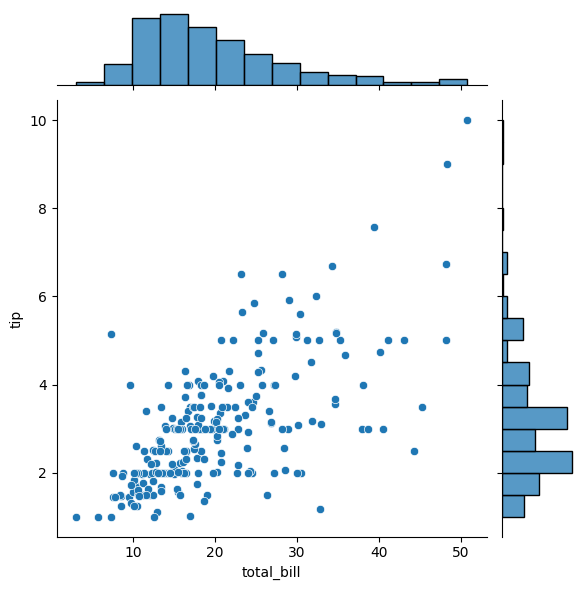

In [138]:
#Jointplot
# Purpose:
# Combines a bivariate plot with univariate distributions of
# each variable, allowing you to analyze both the relationship
# between variables and their individual distributions.

# Best Used For:
# - Exploring relationships between two numerical variables
# - Analyzing individual distributions
# - Detecting correlations and outliers
# - Exploratory Data Analysis (EDA)

# Insight:
# The joint plot shows the relationship between total bill and
# tip using a scatter plot in the center, while the histograms
# along the top and right display the individual distributions
# of total bill and tip. The scatter plot indicates a positive
# relationship, suggesting that customers who spend more
# generally leave higher tips. The marginal histograms reveal
# that most observations are concentrated at lower to moderate
# bill and tip values.

sns.jointplot(data=tips,x='total_bill',y='tip')

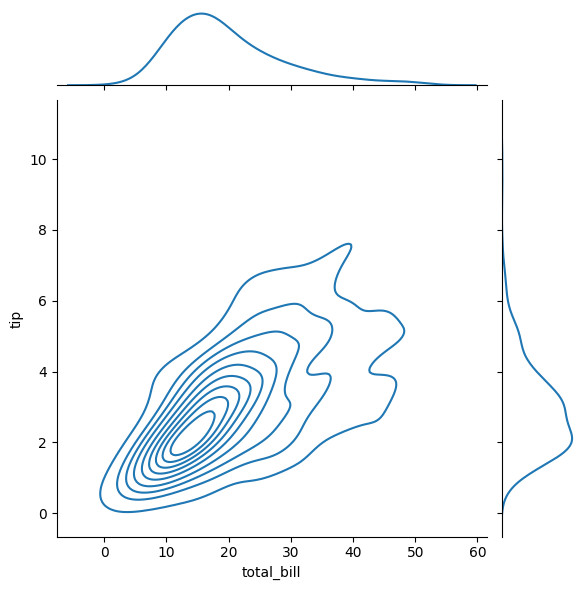

In [139]:
#kind
sns.jointplot(data=tips,x='total_bill',y='tip',kind='kde')

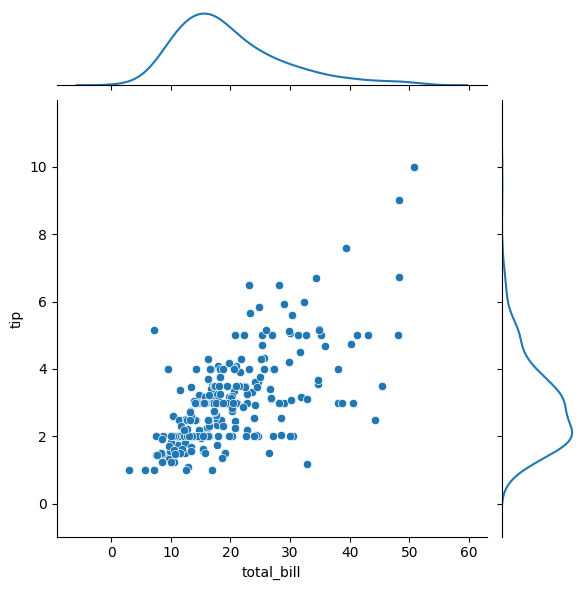

In [140]:
#JointGrid
# Purpose:
# Creates a fully customizable joint plot by allowing different
# plot types for the joint (center) and marginal (side)
# distributions.

# Best Used For:
# - Customizing joint plots
# - Combining different plot types
# - Exploring relationships and distributions
# - Advanced Exploratory Data Analysis (EDA)

# Insight:
# The JointGrid displays a scatter plot in the center to show
# the relationship between total bill and tip, while KDE plots
# on the top and right illustrate the distributions of total
# bill and tip individually. The scatter plot reveals a positive
# relationship, indicating that customers who spend more tend
# to leave higher tips. The KDE plots show that both variables
# are concentrated at lower to moderate values.
g=sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.scatterplot,sns.kdeplot)

**Utility Functions**

In [141]:
sns,sns.get_dataset_names()

(<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>,
 ['anagrams',
  'anscombe',
  'attention',
  'brain_networks',
  'car_crashes',
  'diamonds',
  'dots',
  'dowjones',
  'exercise',
  'flights',
  'fmri',
  'geyser',
  'glue',
  'healthexp',
  'iris',
  'mpg',
  'penguins',
  'planets',
  'seaice',
  'taxis',
  'tips',
  'titanic'])

In [142]:
sns.load_dataset('diamonds')

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


**Key Takeaways**
- Seaborn simplifies statistical visualization.
- Axes-level functions create one plot.
- Figure-level functions create multiple plots.
- Choose the plot based on the type of data and analysis.

# 📌 Which Seaborn Plot Should I Use?

| **Goal** | **Recommended Plot(s)** |
|:-------------------------------|:----------------------------------------------|
| Show trends over time | `lineplot()` |
| Compare two numerical variables | `scatterplot()`, `regplot()` |
| Show relationship with regression | `regplot()` |
| Check regression residuals | `residplot()` |
| Visualize distribution of one variable | `histplot()`, `displot(kind='hist')` |
| Estimate probability density | `kdeplot()`, `displot(kind='kde')` |
| Show individual observations | `rugplot()` |
| Visualize distribution of two variables | `histplot(x, y)`, `kdeplot(x, y)` |
| Compare distributions across categories | `boxplot()`, `violinplot()`, `stripplot()`, `swarmplot()` |
| Compare category averages | `barplot()`, `pointplot()` |
| Count occurrences of categories | `countplot()` |
| Find outliers | `boxplot()`, `stripplot()`, `swarmplot()` |
| Compare spread and density | `violinplot()` |
| Visualize correlation matrix | `heatmap()` |
| Cluster similar observations | `clustermap()` |
| Compare relationships between many variables | `pairplot()` |
| Build customized pairwise plots | `PairGrid()` |
| Compare subsets of data | `FacetGrid()` |
| Analyze two variables with marginal distributions | `jointplot()` |
| Create fully customized joint plots | `JointGrid()` |
| Create figure-level relational plots | `relplot()` |
| Create figure-level distribution plots | `displot()` |
| Create figure-level categorical plots | `catplot()` |
| Create figure-level regression plots | `lmplot()` |

---

## 💡 Quick Selection Guide

### 📈 Trend Analysis
- `lineplot()`

### 🔗 Relationship Between Variables
- `scatterplot()`
- `regplot()`
- `jointplot()`
- `PairGrid()`
- `pairplot()`

### 📊 Distribution Analysis
- `histplot()`
- `kdeplot()`
- `rugplot()`
- `displot()`

### 📦 Compare Categories
- `boxplot()`
- `violinplot()`
- `stripplot()`
- `swarmplot()`
- `barplot()`
- `pointplot()`
- `countplot()`

### 🔥 Matrix Visualization
- `heatmap()`
- `clustermap()`

### 🧩 Multiple Subplots
- `FacetGrid()`
- `JointGrid()`
- `PairGrid()`
- `relplot()`
- `displot()`
- `catplot()`
- `lmplot()`

## 🎯 Conclusion

This notebook demonstrates the most commonly used Seaborn visualizations,
explains when to use each plot, highlights important parameters, and
provides guidance on interpreting the resulting visualizations. It serves
as a practical reference for Exploratory Data Analysis (EDA) and data
visualization projects.